### Imports

In [79]:
%config InlineBackend.figure_format = 'svg'
%load_ext autoreload
%autoreload 2
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import scipy
import pickle
import importlib
import copy
from pathlib import Path
import scipy.io as sio

# Importa i moduli (non le funzioni da dentro)
import ParametersFunctions_SSM
import models_SSM
import SSMs
import neural_ssm
from utils_SSM import set_params, ensure_3d, fun_start_controller, fun_start_controller_simple, plot_glucose_insulin
from torch.utils.data import DataLoader, random_split, Subset, SubsetRandomSampler, Dataset
from ParametersFunctions_SSM import Parameter, PID_functions, MinMaxScalerTorch
from dataset import LoadData, SimpleLoadData

# Ricaricare
importlib.reload(models_SSM)
importlib.reload(SSMs)
importlib.reload(neural_ssm)
importlib.reload(ParametersFunctions_SSM)

# Adesso importa quello che ti serve
from models_SSM import NonLinearController, NonLinearController_p2, ClosedLoopSystem_SSM, monotonic_gain_loss
from SSMs import DualSSM
from neural_ssm import DeepSSM
from ParametersFunctions_SSM import Parameter, PID_functions, MinMaxScalerTorch


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Set parameters

In [ ]:
# Parameters
# ------------
# If ecxecuted with papermill these parameters are overwritten.

patient = globals().get("patient", None)
device = globals().get("device", None)

# if not passed in papermill, set preferred values for manual use
if patient is None:
    patient = 1   # <-- preferred patient for manual use
if device is None:
    device = "cpu"  # <-- preferred device for manual use

# can add like this more optional parameters like batch size, epochs, learning rate, etc.

print(f"[INFO] Training per patient: {patient}    on device: {device}")




# Define simulation parameters
torch.set_default_dtype(torch.float64)

x0, input_dim, output_dim, dim_internal, dim_nl, y_init, IQC_type, gamma, learning_rate, epochs, data_path, model_folder, redo_save, ts, use_noise, num_days, redo_save_101_I, redo_save_101_M, exp_identifier= set_params()

# Closed-loop data

In [ ]:
#-------------------------2. Generate closed loop data---------------------------------------------


# consecutive days split
train_size = int(num_days*0.8*1440//ts)
val_size = int(num_days*0.1*1440//ts)
test_size = int(num_days*0.1*1440//ts)

start_valid = 5*12 # 5 hours of warm-up for validation and test

# it is normalized, has as method also the scaler to denormalize
dataset = LoadData(patient, data_path, use_noise, train_size+start_valid)


val_dataset   = torch.utils.data.Subset(dataset, range(train_size+start_valid, train_size+start_valid + val_size))
test_dataset  = torch.utils.data.Subset(dataset, range(train_size+start_valid + val_size, train_size + val_size + test_size))

val_loader = DataLoader(val_dataset, batch_size=len(val_dataset), shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)



#------------------------- save scalers ---------------------------------------------------

scaler_glucose = dataset.scaler_glucose
scaler_insulin = dataset.scaler_insulin
scaler_meal    = dataset.scaler_meal


if redo_save:
    # Save the scalers
    # 1. Create models directory
    patient_str = "/paz_" + str(int(patient)).zfill(3)
    patient_model_folder = model_folder + "/" + patient_str
    MODEL_PATH = Path(patient_model_folder)
    MODEL_PATH.mkdir(parents = True, exist_ok = True)
    # 2. save model state dict
    torch.save(scaler_glucose, MODEL_PATH / 'scaler_glucose.pth')
    torch.save(scaler_insulin, MODEL_PATH / 'scaler_insulin.pth')
    torch.save(scaler_meal,    MODEL_PATH / 'scaler_meal.pth')
    
    sio.savemat(MODEL_PATH / 'scalers.mat', {
    'glucose_low':  scaler_glucose.params['low'].item(),
    'glucose_high': scaler_glucose.params['high'].item(),
    'insulin_low':  scaler_insulin.params['low'].item(),
    'insulin_high': scaler_insulin.params['high'].item(),
    'meal_low':     scaler_meal.params['low'].item(),
    'meal_high':    scaler_meal.params['high'].item()
})


### Plots: I and R

In [ ]:
CGM   = (scaler_glucose.denormalize(dataset.CGM.detach())).numpy();              G     = (scaler_glucose.denormalize(dataset.G.detach())).numpy()
                                                                                                                                 
I_sat       = (scaler_insulin.denormalize(dataset.I_sat.detach())).numpy();      I_rec = (scaler_insulin.denormalize(dataset.I_rec.detach())).numpy();       
I_sat_rec   = (scaler_insulin.denormalize(dataset.I_sat_rec.detach())).numpy();  R     = (scaler_insulin.denormalize(dataset.R.detach())).numpy()

M       = (scaler_meal.denormalize(dataset.M.detach())).numpy();                 MH    = (scaler_meal.denormalize(dataset.MH.detach())).numpy();          
MH_rec  = (scaler_meal.denormalize(dataset.MH_rec.detach())).numpy()
H       = (scaler_meal.denormalize(dataset.H.detach())).numpy();                 H_rec = (scaler_meal.denormalize(dataset.H_rec.detach())).numpy();     

# R = I_sat (from .mat) - I_rec (exiting the PID and before saturation and noise)
# if  use_noise = True, R contains the noise and the saturation effect


# ------------------------- PID controller dynamic simulation ---------------------------------------------------
CGM_torch = dataset.CGM
time = dataset.time
loaded_parameters = Parameter(patient)
controller = NonLinearController(loaded_parameters, PID_functions, dataset.basal_vec, scaler_glucose, scaler_insulin, scaler_meal, use_noise)
u_pid, u_pid_rwgn, u_pid_rwgn_sat, r = controller(CGM_torch, time)


u_pid           = scaler_insulin.denormalize(u_pid.detach())
u_pid_rwgn      = scaler_insulin.denormalize(u_pid_rwgn.detach())
u_pid_rwgn_sat  = scaler_insulin.denormalize(u_pid_rwgn_sat.detach())
r               = scaler_insulin.denormalize(r.detach())

plt.figure()
plt.plot(I_rec[:2*1440//ts]+ R[:2*1440//ts], label= 'I_rec + R')
plt.plot(u_pid_rwgn_sat.numpy()[:2*1440//ts], label = 'I pid dynamic calculation');             plt.legend();plt.grid(True); plt.show()

plt.figure()
plt.plot(R[:2*1440//ts], label= 'R')
plt.plot(r.numpy()[:2*1440//ts], label = 'R dynamic calculation');                             plt.legend();plt.grid(True); plt.show()


### parallelization batches

In [ ]:
# train start 5 h aafter midnight, every batch 48 h long finishing at 4:55 am


# time definitions
ts_per_hour = 12           # 288 timesteps = 24h → 12 timesteps/hour (5 min each)
hours_per_batch = 48       # 2 days = 48 hours
steps_per_batch = hours_per_batch * ts_per_hour  # 48*12 = 576

start_train = start_valid        #60    [1 element every 5 minutes] I eliminate eqully the first 5 hours from training set

train_dataset = torch.utils.data.Subset(dataset, range(start_train, train_size+start_valid))



# === FUNZIONE: crea blocchi fissi ===
def create_fixed_batches(total_length, chunk_size=576, start_idx=0):
    """
    Divide il dataset in batch temporali fissi (48h).
    Ogni batch è una lista di indici consecutivi.
    L'ultimo batch viene scartato se più corto di chunk_size.
    """
    batches = []
    start = start_idx
    while start + chunk_size <= total_length:
        end = start + chunk_size
        batches.append(list(range(start, end)))
        start = end
    return batches


# === COSTRUISCI I BATCH INDICI ===
train_indices = create_fixed_batches(len(train_dataset), chunk_size=steps_per_batch)

starting_indices = [batch[0] for batch in train_indices]

batch_size=len(starting_indices)

def collate_train_indices(batch):
    """
    batch: lista di 12 sequenze consecutive (ognuna di lunghezza 576)
    batch_size = len(batch) = 12
    """
    # ogni item del batch corrisponde a un indice di train_indices (576 timesteps)
    u0_batch = torch.stack([train_dataset[i][0] for i in batch]) # MH # shape: (12, 576, input_dim)
    u1_batch = torch.stack([train_dataset[i][3] for i in batch]) # I_sat
    ur_batch = torch.stack([train_dataset[i][2] for i in batch]) # r
    y_batch  = torch.stack([train_dataset[i][4] for i in batch])
    time_batch = torch.stack([train_dataset[i][5] for i in batch])
    
    return u0_batch, None, ur_batch, u1_batch, y_batch, time_batch



train_loader_p = DataLoader(
    train_indices,
    batch_size = batch_size,
    shuffle = False,  # oppure True se vuoi mescolare
    collate_fn = collate_train_indices,
    drop_last = True  # opzionale, elimina batch incompleti
)


saturation_error_init, glucose_PID_init, y0_1 = fun_start_controller(train_loader_p, loaded_parameters, scaler_glucose, scaler_insulin, dataset)

y0_0 = torch.zeros_like(y0_1) # meal ren initialized to 0

controller_p2 = NonLinearController_p2(loaded_parameters, PID_functions, dataset.basal_vec, scaler_glucose, scaler_insulin, scaler_meal, use_noise = use_noise)

controller_p2.reset(saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)

# === LOOP DI TRAINING ===
for n_batch, (u0_batch, _, _, u1_batch, y_batch, time_batch) in enumerate(train_loader_p):

    u0_batch, u1_batch, y_batch, time_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)
    u_pid, u_pid_rwgn, u_pid_rwgn_sat, r = controller_p2(CGM = y_batch.squeeze(2), time = time_batch.squeeze(2))
    
r = scaler_insulin.denormalize(r.detach())
for i in range(2):
    plt.figure()
    plt.plot(time_batch[i,:].numpy(), R[time_batch[i,:].squeeze().numpy().astype(int)], label= 'R')
    plt.plot(time_batch[i,:].numpy(), r[i,:].numpy(), label = 'R dynamic calculation');                             plt.legend();plt.grid(True); plt.show()
    
    

# === LOOP DI val ===
# !!! reset va lasciato a 0 solo se parto proprio dall'istante zero, con valid in realtà la simulazione era andata già da un po'

saturation_error_init, glucose_PID_init, y0_1 = fun_start_controller(val_loader, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
controller_p2.reset(saturation_error_init=saturation_error_init, glucose_PID_init=glucose_PID_init)
for u0_batch, _, _, u1_batch, y_batch, time_batch in val_loader:
    
    u0_batch, u1_batch, y_batch, time_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)

    u_pid, u_pid_rwgn, u_pid_rwgn_sat, r = controller_p2(CGM = y_batch.squeeze(2), time = time_batch.squeeze(2))
    
r = scaler_insulin.denormalize(r.detach())

plt.figure()
plt.plot(time_batch[0,:].numpy(), R[time_batch[0,:].squeeze().numpy().astype(int)], label= 'R')
plt.plot(time_batch[0,:].numpy(), r[0,:].numpy(), label = 'R dynamic calculation');                             plt.legend();plt.grid(True); plt.show()

### other plots

In [ ]:
plt.figure(1, figsize=(12, 8))

# Subplot 1
ax1 = plt.subplot(2, 1, 1)
ax1.plot(CGM[:], 'b-', label='Glucose sensor CGM')
ax1.plot(G[:], 'gray', label='Glucose');                                                               ax1.set_ylabel('Glucose', color='b'); ax1.tick_params(axis='y', labelcolor='b'); ax1_right = ax1.twinx()
MHtemp = MH[:].copy()
ax1_right.scatter(np.arange(len(MHtemp))[MHtemp!=0], MHtemp[MHtemp!=0], color='g', label='Meals and hypo');         ax1_right.set_ylabel('Meals', color='b'); ax1_right.tick_params(axis='y', labelcolor='g'); plt.grid(True)

# Subplot 2
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
ax2.plot(range(len(I_sat[:])), I_sat[:].flatten(), label='I_sat')
ax2.plot(range(len(I_sat_rec[:])), I_sat_rec[:], label='I_sat_rec');                                      ax2.set_ylim([0, np.max(I_sat_rec) * 1.1]); ax2.legend(); ax2.set_xlabel('Time Index'); ax2.set_ylabel('Insulin')

plt.tight_layout(); plt.grid(True); plt.show()



plt.figure(3, figsize=(12, 8))
plt.plot(I_rec[:1440//4]+ R[:1440//4], label = 'I_rec(calculated by PID) + R')
plt.plot(I_sat[:1440//4], label= 'I_sat (from the data already saturated)')
plt.title('I saturated, They need to be equal,   R = I_sat - I_rec');                   plt.legend();plt.grid(True); plt.show()

plt.figure(4, figsize=(12, 8))
plt.plot(R[:1440//4], label= 'R')
plt.plot(I_rec[:1440//4]+ R[:1440//4], label= 'I_rec + R')
plt.plot(I_rec[:1440//4], label = 'I_rec  (calculated by PID)');                             plt.legend();plt.grid(True); plt.show()


# plt.figure(5)
# plt.plot(H, label='H')
# plt.plot(H_rec-100, label='H_rec')
# plt.title('Hypoglycemia Treatments Comparison');                                                    plt.legend(); plt.show()
#
# plt.figure(6)
# plt.plot(CGM[:1440//4], 'b-', label='Glucose sensor CGM')
# plt.plot(G[:1440//4], 'gray', label='Glucose')
# plt.figure(1, figsize=(12, 8))


# Patient 101

### define dataset 101

In [ ]:
dataset_101_I = SimpleLoadData('./data/train/30days_101_I_v2/', 101,scaler_insulin, scaler_glucose, scaler_meal)
dataset_101_M = SimpleLoadData('./data/train/30days_101_M/', 101,scaler_insulin, scaler_glucose, scaler_meal)

train_dataset_101_I = torch.utils.data.Subset(dataset_101_I, range(start_train, train_size+start_valid))
train_dataset_101_M = torch.utils.data.Subset(dataset_101_M, range(start_train, train_size+start_valid))

val_dataset_101_I   = torch.utils.data.Subset(dataset_101_I, range(train_size+start_valid, train_size+start_valid + val_size))
val_dataset_101_M   = torch.utils.data.Subset(dataset_101_M, range(train_size+start_valid, train_size+start_valid + val_size))
test_dataset_101_I  = torch.utils.data.Subset(dataset_101_I, range(train_size+start_valid + val_size, train_size + val_size + test_size))
test_dataset_101_M  = torch.utils.data.Subset(dataset_101_M, range(train_size+start_valid + val_size, train_size + val_size + test_size))

val_loader_101_I = DataLoader(val_dataset_101_I, batch_size=len(val_dataset_101_I), shuffle=False)
val_loader_101_M = DataLoader(val_dataset_101_M, batch_size=len(val_dataset_101_M), shuffle=False)
test_loader_101_I = DataLoader(test_dataset_101_I, batch_size=len(test_dataset_101_I), shuffle=False)
test_loader_101_M = DataLoader(test_dataset_101_M, batch_size=len(test_dataset_101_M), shuffle=False)


def collate_train_indices_101_I(batch):
    """
    batch: lista di 12 sequenze consecutive (ognuna di lunghezza 576)
    batch_size = len(batch) = 12
    """
    # ogni item del batch corrisponde a un indice di train_indices (576 timesteps)
    u0_batch = torch.stack([train_dataset_101_I[i][0] for i in batch]) # MH 
    u1_batch = torch.stack([train_dataset_101_I[i][1] for i in batch]) # I_sat   (no RWGN)
    y_batch = torch.stack([train_dataset_101_I[i][2] for i in batch]) # y
    time_batch = torch.stack([train_dataset_101_I[i][3] for i in batch])

    return u0_batch, u1_batch, y_batch, time_batch

def collate_train_indices_101_M(batch):
    """
    batch: lista di 12 sequenze consecutive (ognuna di lunghezza 576)
    batch_size = len(batch) = 12
    """
    # ogni item del batch corrisponde a un indice di train_indices (576 timesteps)
    u0_batch = torch.stack([train_dataset_101_M[i][0] for i in batch]) # MH 
    u1_batch = torch.stack([train_dataset_101_M[i][1] for i in batch]) # I_sat   (no RWGN)
    y_batch = torch.stack([train_dataset_101_M[i][2] for i in batch]) # y
    time_batch = torch.stack([train_dataset_101_M[i][3] for i in batch])

    return u0_batch, u1_batch, y_batch, time_batch


train_loader_p_101_I = DataLoader(
    train_indices,
    batch_size = batch_size,
    shuffle = False,  # oppure True se vuoi mescolare
    collate_fn = collate_train_indices_101_I,
    drop_last = True  # opzionale, elimina batch incompleti
)

train_loader_p_101_M = DataLoader(
    train_indices,
    batch_size = batch_size,
    shuffle = False,  # oppure True se vuoi mescolare
    collate_fn = collate_train_indices_101_M,
    drop_last = True  # opzionale, elimina batch incompleti
)



### REN model 101, loss function and optimizer parallel
as strategy 1

In [ ]:
#--------------------------3. Define model for sysid---------------------------------------------


device = torch.device(device if torch.cuda.is_available() else "cpu")

y0_1 = fun_start_controller_simple(train_loader_p_101_I, dataset_101_I)
y0_0 = torch.zeros_like(y0_1) # meal ren initialized to 0


# TODO: gamma diverso per i 101

# SSM_0_101 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8, d_state=8, n_layers = 8, ff='GLU', param='l2n')  #lru   l2n gamma prescritto

SSM_0_101 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8, d_state=8, n_layers=7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)  


# SSM_1_101 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8, d_state=8, n_layers = 7, ff='GLU',param='l2n')

SSM_1_101 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)

SSM_0_101 = SSM_0_101.to(device)
SSM_1_101 = SSM_1_101.to(device)

#create the closed loop with the identified model
# closed_loop_G = ClosedLoopSystem(REN_G, controller)

#--------------------------4. Define the loss function and optimizer---------------------------------------------
MSE = nn.MSELoss()


### Training and validation loop 

#### 101 I

In [ ]:
epochs = 2000
learning_rate = 1e-3

optimizer = torch.optim.Adam( list(SSM_1_101.parameters()),   lr=learning_rate)
optimizer.zero_grad()

importlib.reload(models_SSM)
from models_SSM import NonLinearController, NonLinearController_p2, ClosedLoopSystem_SSM, monotonic_gain_loss

#--------------------------5. Training---------------------------------------------------------------------

torch.set_default_device(device)      # default tensor device
torch.set_default_dtype(torch.float32)  # default tensor dtype
print(f"[INFO] Training on device: {device}")

SSM_1_101.to(device)
train_losses = []
val_losses = []  # Store validation losses across epochs
for epoch in range(epochs):
    # ---------------- TRAINING ---------------- #
    SSM_1_101.train()
    loss_epoch = 0.0  # Accumulate training loss
    loss_I_epoch = 0.0  # Accumulate training loss I

    for _, u1_batch, y_batch, time_batch in train_loader_p_101_I: # MH, I_rec , CGM, time        

        u1_batch, y_batch, time_batch = ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)
        u1_batch, y_batch, time_batch = u1_batch.to(device), y_batch.to(device), time_batch.to(device)
        
        optimizer.zero_grad()
        

        # y_init_per_batch      torch.zeros_like(y_batch[:,:1])    y_batch[:,:1]
        y1_hat_train = SSM_1_101(u1_batch) # forward
        y_hat_train = -y1_hat_train[0]
        # with monotonicity we have forced a positive response from the insulin REN (REN_1) 
        # but from real-world knowledge it is a negative relation

        loss_batch_train = MSE(y_hat_train, y_batch)
        
        loss_I_train = monotonic_gain_loss(y_hat_train, u1_batch, scaler_glucose, scaler_insulin, 
                                                        evaluate = 'insulin', 
                                                        cumulative_window = 12*1.5, 
                                                        horizon=12*1.5, 
                                                        aggressive_coeff=0.7, 
                                                        CR = loaded_parameters.Patient_par.CR_101,
                                                        CF = loaded_parameters.Patient_par.CF_101)
        
        loss_I_train = 0.0

        total_loss_train = loss_batch_train + loss_I_train

        total_loss_train.backward()
        optimizer.step()
        loss_epoch += total_loss_train.item()
        loss_I_epoch += loss_I_train.item()
        
    loss_epoch /= len(train_loader_p)
    loss_I_epoch /= len(train_loader_p)
    train_losses.append(loss_epoch)

    # ---------------- VALIDATION ---------------- #
    SSM_1_101.eval()
    loss_val_epoch = 0.0
    loss_I_val_epoch = 0.0

    with torch.no_grad():
        for _, u1_batch, y_batch, time_batch in val_loader_101_I: # MH, I_rec (PID), CGM, time
            
            u1_batch, y_batch, time_batch = ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)
            u1_batch, y_batch, time_batch = u1_batch.to(device), y_batch.to(device), time_batch.to(device)
            

            y1_hat_val = SSM_1_101(u1_batch)# select the correct U
            y_hat_val = -y1_hat_val[0]
            
            loss_batch_val = MSE(y_hat_val, y_batch)
            
            loss_I_val = monotonic_gain_loss(y_hat_val, u1_batch, scaler_glucose, scaler_insulin, 
                                                        evaluate = 'insulin', 
                                                        cumulative_window = 12*1.5, 
                                                        horizon=12*1.5, 
                                                        aggressive_coeff=0.7, 
                                                        CR = loaded_parameters.Patient_par.CR_101,
                                                        CF = loaded_parameters.Patient_par.CF_101)
        
            total_loss_val = loss_batch_val + loss_I_val
            loss_I_val_epoch += loss_I_val.item()

    if epoch == 0 or loss_val_epoch < min_val_loss:
        min_val_loss = loss_val_epoch
        epoch_when_model_saved = epoch
        
        candidate_SSM_1_101 = SSM_1_101

    loss_val_epoch /= len(val_loader)
    loss_I_val_epoch /= len(val_loader)
    val_losses.append(loss_val_epoch)  # Store validation loss for plotting

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} \t||\t"
              f"Train L: {loss_epoch:.6f}   \t||\t Train L_I: {loss_I_epoch:.6f} \t||\t"
              f"Val L: {loss_val_epoch:.6f} \t||\t Val L_I: {loss_I_val_epoch:.6f}")


patient_model_folder_101_I = f"./models/SSM/101_I/{exp_identifier}"
if redo_save_101_I:
    # model on CPU before saving
    candidate_SSM_1_101_cpu = candidate_SSM_1_101.to('cpu')

    # Save the best model
    # 1. Create models directory
    MODEL_PATH = Path(patient_model_folder_101_I)
    MODEL_PATH.mkdir(parents = True, exist_ok = True)
    # 2. save model state dict
    torch.save({
    'SSM_1_101_state_dict': candidate_SSM_1_101_cpu.state_dict()}, MODEL_PATH / 'trained_models.pth')


    # save .mat
    np_x0 = x0.detach().cpu().numpy(); np_input_dim = np.array(input_dim); np_output_dim = np.array(output_dim); np_dim_internal =np.array(dim_internal); np_dim_nl = np.array(dim_nl)
    np_y_init = y_init.cpu().numpy(); np_gamma = gamma.cpu().numpy()
    
    # 4. Create params directory
    params_folder = Path(patient_model_folder_101_I) / "params"
    params_folder.mkdir(parents=True, exist_ok=True)
    scipy.io.savemat(params_folder / 'parameters.mat', {'train_losses': train_losses, 'val_losses': val_losses, 'epoch_when_model_saved': epoch_when_model_saved, 'x0': np_x0, 'input_dim': np_input_dim, 'output_dim': np_output_dim, 'dim_internal': np_dim_internal, 'dim_nl': np_dim_nl, 'y_init': np_y_init, 'gamma': np_gamma})

#### test 101 I

C:\Users\pmong\AppData\Local\Temp\ipykernel_16852\2024120042.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  epoch_best   = int(params["epoch_when_model_saved"][0])


epoca migliore: 1999


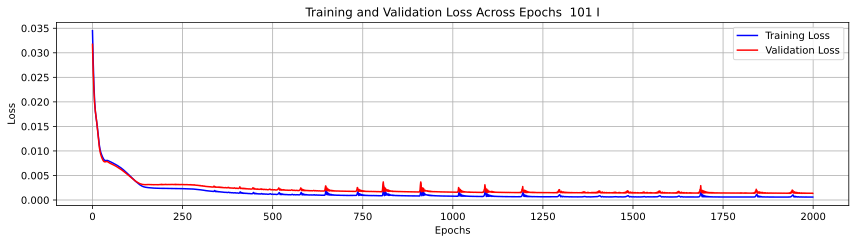

Loss train: 0.0006058691651560366


c:\Users\pmong\OneDrive - Università di Pavia\EPFL\Nonlinear_system_identification_modified\utils_SSM.py:251: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


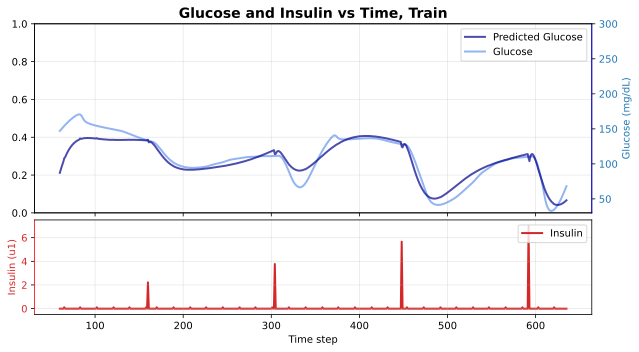

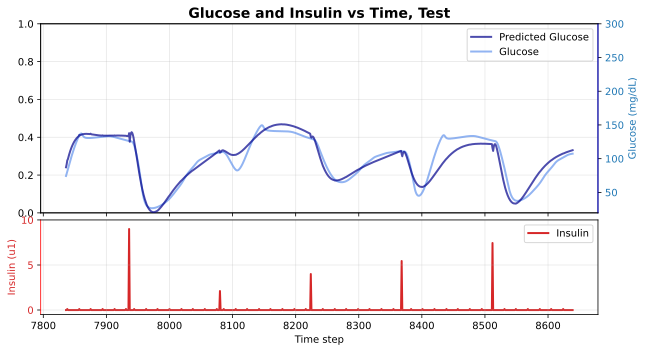

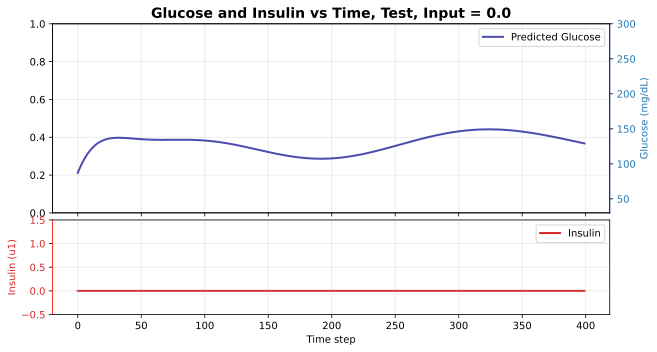

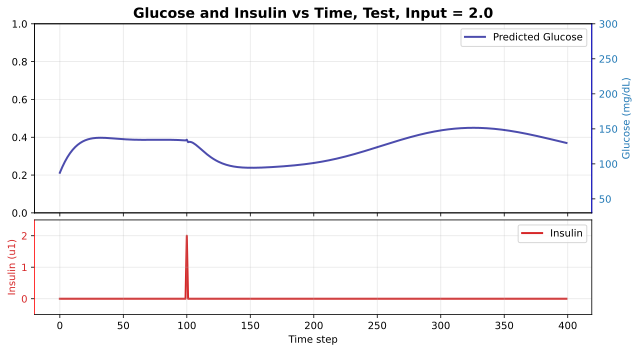

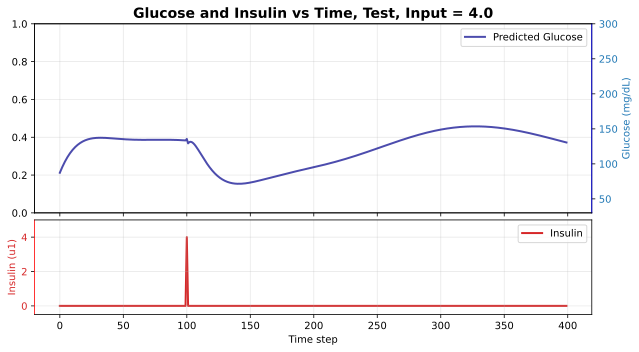

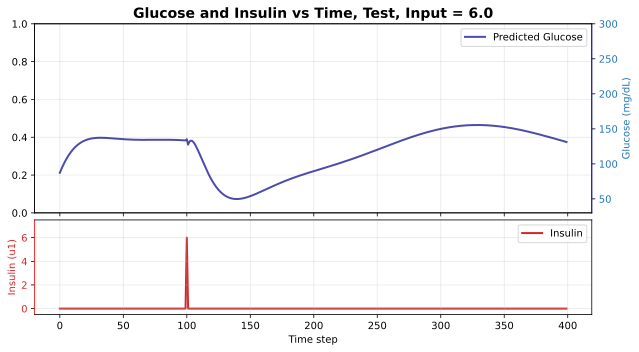

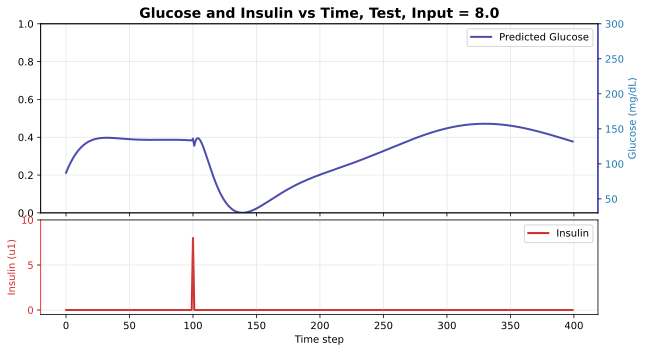

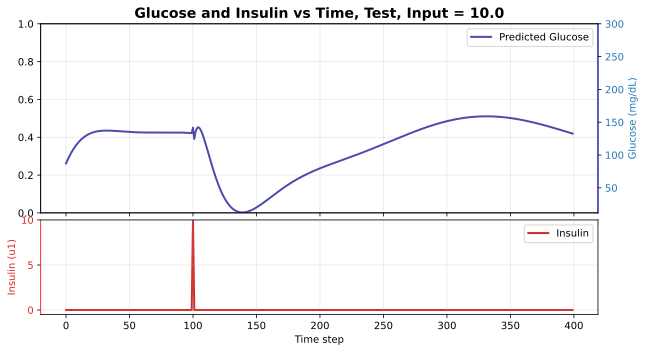

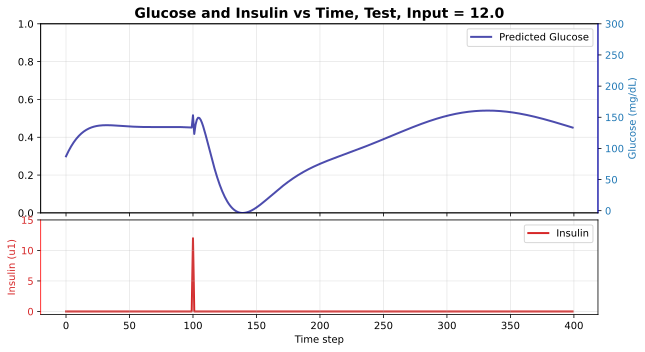

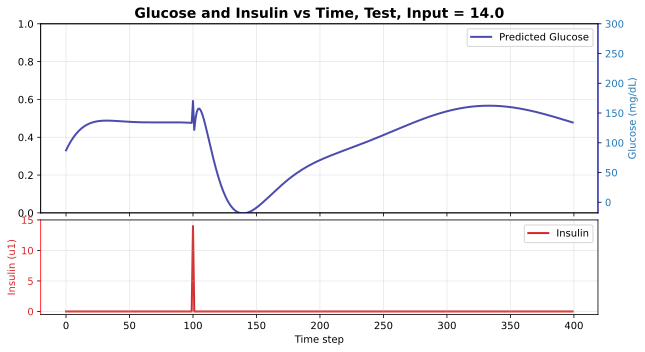

In [62]:

# --------------Plot identification results for G-----------------

patient_model_folder_101_I = f"./models/SSM/101_I/{exp_identifier}"
MODEL_PATH = Path(patient_model_folder_101_I)
PARAM_PATH = MODEL_PATH / "params" / "parameters.mat"
params = scipy.io.loadmat(PARAM_PATH)

x0          = torch.tensor(params['x0'])
input_dim   = params["input_dim"].flatten().astype(int).tolist()
output_dim  = params["output_dim"].flatten().astype(int).tolist()
dim_internal= params["dim_internal"].flatten().astype(int).tolist()
dim_nl      = params["dim_nl"].flatten().astype(int).tolist()

y_init      = torch.tensor(params['y_init'])
gamma       = torch.tensor(params['gamma']).flatten()

train_losses = params["train_losses"][0]
val_losses   = params["val_losses"][0]
epoch_best   = int(params["epoch_when_model_saved"][0])

print(f"epoca migliore: {epoch_best}")

epochs = 2000

# ----------------------------------

#Training and Validation Loss Across Epochs
plt.figure(figsize=(12, 3.5))
plt.plot(range(epochs), train_losses, label='Training Loss', color='blue')
plt.plot(range(epochs), val_losses, label='Validation Loss', color='red')  # Assuming val_losses are collected
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Epochs  101 I')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------

SSM_1_101 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8,  n_layers = 7, ff='GLU',param='l2n',
                    d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)


checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_1_101.load_state_dict(checkpoint["SSM_1_101_state_dict"])

#################################################################

for _, u1_batch, y_batch, time_batch in train_loader_p_101_I:

    u1_batch, y_batch, time_batch = ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)
    
    y1_hat = SSM_1_101(u1_batch)
    y_hat = -y1_hat[0]
    
    loss_train = MSE(y_hat, y_batch)

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    
    break # just first batch

print(f"Loss train: {loss_train}")


plot_glucose_insulin(time_batch[0,:,0].numpy(), insulin = u1_batch[0,:,0].numpy(), glucose=y_batch_np[0,:,0], predicted_glucose=y_hat_np[0,:,0], title='Glucose and Insulin vs Time, Train')



#####################################################################################



for _, u1_batch, y_batch, time_batch in test_loader_101_I:

    u1_batch, y_batch, time_batch = ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)

    y1_hat = SSM_1_101(u1_batch)
    y_hat = -y1_hat[0]

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    

plot_glucose_insulin(time_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(), glucose=y_batch_np[0,:,0], predicted_glucose=y_hat_np[0,:,0], title='Glucose and Insulin vs Time, Test')


# prima non era propriamente corretto, controllare ora se propriamente corretto: il modello è il closed loop non il dual ren
# in questo modo vedo se effettivamente la condizione di monotonicità è rispettata o cisono degli errori in giro
# ------------------------- fake insulin ------------------------------------

fake_insulins = [0, 2, 4, 6, 8, 10, 12, 14]

for sample in  fake_insulins:

    Sim_time = 2000
    Ts = 5
    fake_time = np.arange(0, Sim_time, Ts)

    fake_meal = np.zeros(Sim_time//Ts)
    fake_meal = torch.from_numpy(fake_meal).float()

    fake_insulin = np.zeros(Sim_time//Ts)
    fake_insulin[100] = sample
    fake_insulin = torch.from_numpy(fake_insulin).float()

    fake_meal = fake_meal[None,:, None];   fake_insulin = fake_insulin[None,:, None]
    SSM_0_101.eval();                          SSM_1_101.eval()


    y1_hat, _ = SSM_1_101(fake_insulin)
    y_hat =  - y1_hat
    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time = torch.arange(len(y_fake[0,:,0]))[None,:,None]

    plot_glucose_insulin(time[0,:,0].numpy(), insulin=fake_insulin[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_insulin[0,100,0].numpy()}")


#### 101 M

In [ ]:
epochs = 2000
learning_rate = 1e-3

optimizer = torch.optim.Adam( list(SSM_0_101.parameters()),   lr=learning_rate)
optimizer.zero_grad()

#--------------------------5. Training---------------------------------------------------------------------

torch.set_default_device(device)      # default tensor device
torch.set_default_dtype(torch.float32)  # default tensor dtype
print(f"[INFO] Training on device: {device}")

SSM_0_101.to(device)
train_losses = []
val_losses = []  # Store validation losses across epochs
for epoch in range(epochs):
    # ---------------- TRAINING ---------------- #
    SSM_0_101.train()
    loss_epoch = 0.0  # Accumulate training loss

    
    for u0_batch, _, y_batch, time_batch in train_loader_p_101_M: # MH, I_rec (PID), CGM, time

        

        u0_batch, y_batch, time_batch = ensure_3d(u0_batch), ensure_3d(y_batch), ensure_3d(time_batch)
        u0_batch, y_batch, time_batch = u0_batch.to(device), y_batch.to(device), time_batch.to(device)
        
        optimizer.zero_grad()
        

        # y_init_per_batch      torch.zeros_like(y_batch[:,:1])    y_batch[:,:1]
        y0_hat_train = SSM_0_101(u0_batch) # forward
        y_hat_train = y0_hat_train[0]
        # with monotonicity we have forced a positive response from the insulin REN (REN_1) 
        # but from real-world knowledge it is a negative relation

        loss_batch = MSE(y_hat_train, y_batch)

        loss_batch.backward()
        optimizer.step()
        loss_epoch += loss_batch.item()

    loss_epoch /= len(train_loader_p)
    train_losses.append(loss_epoch)

    # ---------------- VALIDATION ---------------- #
    SSM_0_101.eval()
    loss_val_epoch = 0.0

    with torch.no_grad():
        for u0_batch, _, y_batch, time_batch in val_loader_101_M: # MH, I_rec (PID), CGM, time

            u0_batch, y_batch, time_batch = ensure_3d(u0_batch), ensure_3d(y_batch), ensure_3d(time_batch)
            u0_batch, y_batch, time_batch = u0_batch.to(device), y_batch.to(device), time_batch.to(device)
            

            y0_hat_val = SSM_0_101(u0_batch)# select the correct U
            y_hat_val = y0_hat_val[0]
            
            loss_batch_val = MSE(y_hat_val, y_batch)

            loss_val_epoch += loss_batch_val.item()

    if epoch == 0 or loss_val_epoch < min_val_loss:
        min_val_loss = loss_val_epoch
        epoch_when_model_saved = epoch
        
        candidate_SSM_0_101 = SSM_0_101

    loss_val_epoch /= len(val_loader)
    val_losses.append(loss_val_epoch)  # Store validation loss for plotting

    if epoch % 100 == 0:
        print(f"Epoch: {epoch + 1} \t||\t Training Loss: {loss_epoch:.6f} \t||\t Validation Loss: {loss_val_epoch:.6f}")


patient_model_folder_101_M = f"./models/SSM/101_M/{exp_identifier}"
if redo_save_101_M:
    # model on CPU before saving
    candidate_SSM_0_101_cpu = candidate_SSM_0_101.to('cpu')

    # Save the best model
    # 1. Create models directory
    MODEL_PATH = Path(patient_model_folder_101_M)
    MODEL_PATH.mkdir(parents = True, exist_ok = True)
    # 2. save model state dict
    torch.save({
    'SSM_0_101_state_dict': candidate_SSM_0_101_cpu.state_dict()}, MODEL_PATH / 'trained_models.pth')


    # save .mat
    np_x0 = x0.detach().cpu().numpy(); np_input_dim = np.array(input_dim); np_output_dim = np.array(output_dim); np_dim_internal =np.array(dim_internal); np_dim_nl = np.array(dim_nl)
    np_y_init = y_init.cpu().numpy(); np_gamma = gamma.cpu().numpy()
    
    # 4. Create params directory
    params_folder = Path(patient_model_folder_101_M) / "params"
    params_folder.mkdir(parents=True, exist_ok=True)
    scipy.io.savemat(params_folder / 'parameters.mat', {'train_losses': train_losses, 'val_losses': val_losses, 'epoch_when_model_saved': epoch_when_model_saved, 'x0': np_x0, 'input_dim': np_input_dim, 'output_dim': np_output_dim, 'dim_internal': np_dim_internal, 'dim_nl': np_dim_nl, 'y_init': np_y_init, 'gamma': np_gamma})

#### test 101 M

C:\Users\pmong\AppData\Local\Temp\ipykernel_16852\906914353.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  epoch_best   = int(params["epoch_when_model_saved"][0])


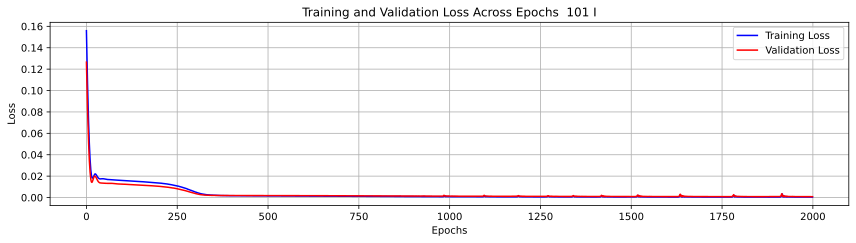

Loss train: 0.00041347689693793654


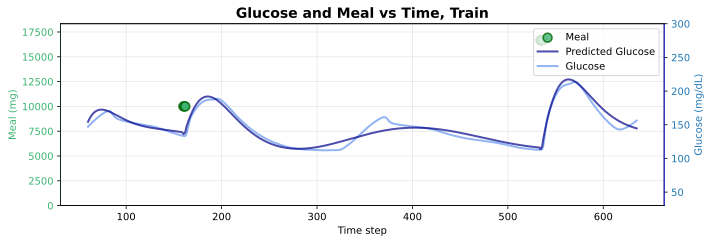

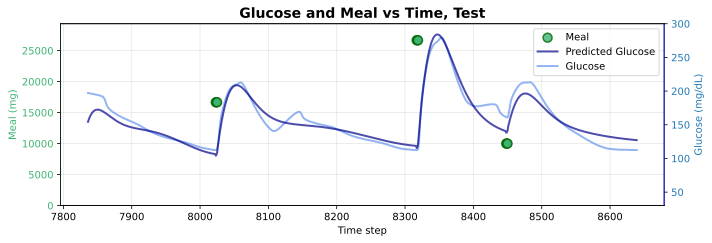

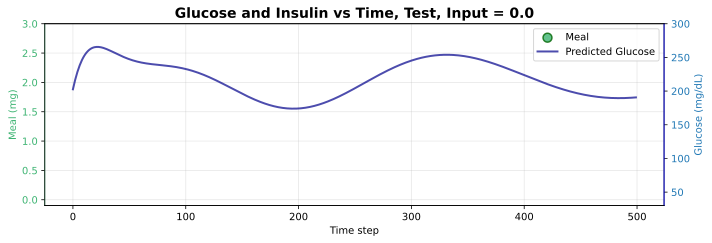

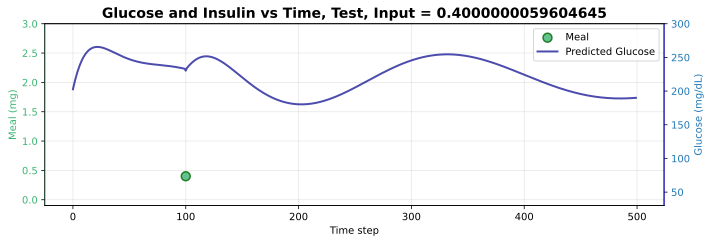

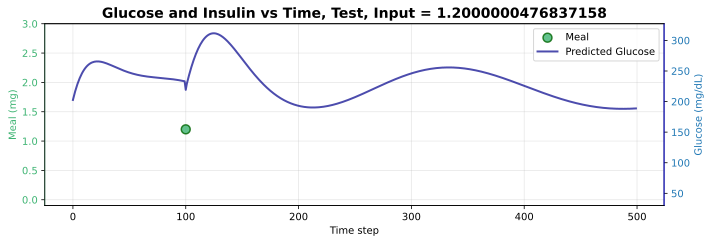

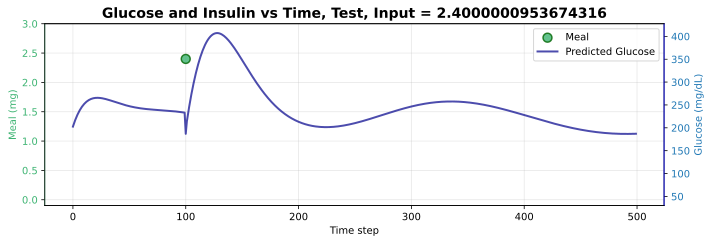

In [80]:

# --------------Plot identification results for G-----------------

patient_model_folder_101_M = f"./models/SSM/101_M/{exp_identifier}"
MODEL_PATH = Path(patient_model_folder_101_M)
PARAM_PATH = MODEL_PATH / "params" / "parameters.mat"
params = scipy.io.loadmat(PARAM_PATH)

x0          = torch.tensor(params['x0'])
input_dim   = params["input_dim"].flatten().astype(int).tolist()
output_dim  = params["output_dim"].flatten().astype(int).tolist()
dim_internal= params["dim_internal"].flatten().astype(int).tolist()
dim_nl      = params["dim_nl"].flatten().astype(int).tolist()

y_init      = torch.tensor(params['y_init'])
gamma       = torch.tensor(params['gamma']).flatten()

train_losses = params["train_losses"][0]
val_losses   = params["val_losses"][0]
epoch_best   = int(params["epoch_when_model_saved"][0])

# ----------------------------------

epochs = 2000

#Training and Validation Loss Across Epochs
plt.figure(figsize=(12, 3.5))
plt.plot(range(epochs), train_losses, label='Training Loss', color='blue')
plt.plot(range(epochs), val_losses, label='Validation Loss', color='red')  # Assuming val_losses are collected
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Epochs  101 I')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()



SSM_0_101 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8, ff='GLU', param='l2n',
                    d_state=8, n_layers=7, max_phase_b=0.04,  d_hidden=12, dim_amp=3)  



checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_0_101.load_state_dict(checkpoint["SSM_0_101_state_dict"])

#################################################################

for u0_batch, _, y_batch, time_batch in train_loader_p_101_M:

    u0_batch, y_batch, time_batch = ensure_3d(u0_batch), ensure_3d(y_batch), ensure_3d(time_batch)
    

    y0_hat = SSM_0_101(u0_batch)
    y_hat = y0_hat[0]
    
    loss_train = MSE(y_hat, y_batch)

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    u0_batch_np = scaler_meal.denormalize(u0_batch.detach().cpu()).numpy()
    
    break # just first batch

print(f"Loss train: {loss_train}")
plot_glucose_insulin(time_batch[0,:,0].numpy(), meal=u0_batch_np[0,:,0], glucose=y_batch_np[0,:,0], predicted_glucose=y_hat_np[0,:,0], title='Glucose and Meal vs Time, Train')



#####################################################################################


for u0_batch, _, y_batch, time_batch in test_loader_101_M:

    u0_batch, y_batch, time_batch = ensure_3d(u0_batch), ensure_3d(y_batch), ensure_3d(time_batch)

    y0_hat = SSM_0_101(u0_batch)
    y_hat = y0_hat[0]

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    u0_batch_np = scaler_meal.denormalize(u0_batch.detach().cpu()).numpy()


plot_glucose_insulin(time_batch[0,:,0].numpy(), meal=u0_batch_np[0,:,0], glucose=y_batch_np[0,:,0], predicted_glucose=y_hat_np[0,:,0], title='Glucose and Meal vs Time, Test')


# ------------------------- fake meal ------------------------------------

fake_meals = [0, 0.4, 0.4*3, 0.4*6]

for sample in  fake_meals:

    fake_meal = np.zeros(500)
    fake_meal[100] = sample 
    fake_meal = torch.from_numpy(fake_meal).float()
    fake_insulin = np.zeros(500)
    fake_insulin = torch.from_numpy(fake_insulin).float()

    fake_meal = fake_meal[None,:, None];    fake_insulin = fake_insulin[None,:, None]
    SSM_0_101.eval();                           SSM_1_101.eval()

    # fake_meal = scaler_glucose.normalize(fake_meal)

    y0_hat, _ = SSM_0_101(fake_meal)
    y1_hat, _ = SSM_1_101(fake_insulin)
    y_hat = y0_hat - y1_hat
    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()


    time = torch.arange(len(y_fake[0,:,0]))[None,:,None]
    # fake_meal = scaler_glucose.denormalize(fake_meal)

    plot_glucose_insulin(time[0,:,0].numpy(), meal=fake_meal[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_meal[0,100,0].numpy()}")




# 1 System identification of G

### REN model, loss function and optimizer parallel

In [ ]:
#--------------------------3. Define model for sysid---------------------------------------------

patient_model_folder_101_I = f"./models/SSM/101_I/{exp_identifier}"
MODEL_PATH = Path(patient_model_folder_101_I)
checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_1_101.load_state_dict(checkpoint["SSM_1_101_state_dict"])

patient_model_folder_101_M = f"./models/SSM/101_M/{exp_identifier}"
MODEL_PATH = Path(patient_model_folder_101_M)
checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_0_101.load_state_dict(checkpoint["SSM_0_101_state_dict"])


device = torch.device(device if torch.cuda.is_available() else "cpu")

SSM_0 = copy.deepcopy(SSM_0_101.to(device))
SSM_1 = copy.deepcopy(SSM_1_101.to(device))

#--------------------------4. Define the loss function and optimizer---------------------------------------------
MSE = nn.MSELoss()

optimizer = torch.optim.Adam( list(SSM_0.parameters()) + list(SSM_1.parameters()),   lr=learning_rate)
optimizer.zero_grad()

### Training and validation loop parallel

In [ ]:
#--------------------------5. Training---------------------------------------------------------------------

importlib.reload(models_SSM)
from models_SSM import NonLinearController, NonLinearController_p2, ClosedLoopSystem_SSM, monotonic_gain_los

torch.set_default_device(device)      # default tensor device
torch.set_default_dtype(torch.float32)  # default tensor dtype
print(f"[INFO] Training on device: {device}")

SSM_0.to(device); SSM_1.to(device)
train_losses = []
val_losses = []  # Store validation losses across epochs
for epoch in range(epochs):
    # ---------------- TRAINING ---------------- #
    SSM_0.train(); SSM_1.train()
    loss_epoch = 0.0  # Accumulate training loss

    
    for u0_batch, _, _, u1_batch, y_batch, _ in train_loader_p: # MH, I_rec (PID), R (noise + sat), I_sat (I_rec + R), CGM, time

        
        u0_batch, u1_batch, y_batch= ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch) 
        # batch_size, time_horizon, input_dim
        u0_batch, u1_batch, y_batch = u0_batch.to(device), u1_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()

        y0_hat_train, _ = SSM_0(u0_batch) # forward
        y1_hat_train, _ = SSM_1(u1_batch) # forward
        y_hat_train = y0_hat_train - y1_hat_train 

        loss_batch = MSE(y_hat_train, y_batch)
        
        monotonic_gain_loss_value = monotonic_gain_loss(y_hat_train, u1_batch, scaler_glucose, scaler_insulin, 
                                                        evaluate = 'meal', 
                                                        cumulative_window = 12*1.5, 
                                                        horizon=12*1.5, 
                                                        aggressive_coeff=0.7, 
                                                        CR = loaded_parameters.Patient_par.CR,
                                                        CF = loaded_parameters.Patient_par.CF)

        loss_batch.backward()
        optimizer.step()
        loss_epoch += loss_batch.item()

    loss_epoch /= len(train_loader_p)
    train_losses.append(loss_epoch)

    # ---------------- VALIDATION ---------------- #
    SSM_0.eval(); SSM_1.eval()
    loss_val_epoch = 0.0

    with torch.no_grad():
        for u0_batch, _, _, u1_batch, y_batch, _ in val_loader: # MH, I_rec (PID), R (noise + sat), I_sat (I_rec + R), CGM, time

            u0_batch, u1_batch, y_batch= ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch)
            u0_batch, u1_batch, y_batch = u0_batch.to(device), u1_batch.to(device), y_batch.to(device)

            y0_hat_val, _ = SSM_0(u0_batch)
            y1_hat_val, _ = SSM_1(u1_batch)# select the correct U
            y_hat_val = y0_hat_val - y1_hat_val
            
            loss_batch_val = MSE(y_hat_val, y_batch)

            loss_val_epoch += loss_batch_val.item()

    if epoch == 0 or loss_val_epoch < min_val_loss:
        min_val_loss = loss_val_epoch
        epoch_when_model_saved = epoch
        candidate_SSM_0 = SSM_0
        candidate_SSM_1 = SSM_1

    loss_val_epoch /= len(val_loader)
    val_losses.append(loss_val_epoch)  # Store validation loss for plotting

    if epoch % 100 == 0:
        print(f"Epoch: {epoch + 1} \t||\t Training Loss: {loss_epoch:.6f} \t||\t Validation Loss: {loss_val_epoch:.6f}")

if redo_save:
    # model on CPU before saving
    candidate_SSM_0_cpu = candidate_SSM_0.to('cpu')
    candidate_SSM_1_cpu = candidate_SSM_1.to('cpu')

    # Save the best model
    # 1. Create models directory
    patient_str = "/paz_" + str(int(patient)).zfill(3)
    patient_model_folder = model_folder + "/"+ "strategy_1" + "/" + patient_str
    MODEL_PATH = Path(patient_model_folder)
    MODEL_PATH.mkdir(parents = True, exist_ok = True)
    # 2. save model state dict
    torch.save({
    'SSM_0_state_dict': candidate_SSM_0_cpu.state_dict(),
    'SSM_1_state_dict': candidate_SSM_1_cpu.state_dict()}, MODEL_PATH / 'trained_models.pth')


    # save .mat
    np_x0 = x0.detach().cpu().numpy(); np_input_dim = np.array(input_dim); np_output_dim = np.array(output_dim); np_dim_internal =np.array(dim_internal); np_dim_nl = np.array(dim_nl)
    np_y_init = y_init.cpu().numpy(); np_gamma = gamma.cpu().numpy()
    
    # 4. Create params directory
    params_folder = Path(patient_model_folder) / "params"
    params_folder.mkdir(parents=True, exist_ok=True)
    scipy.io.savemat(params_folder / 'parameters.mat', {'train_losses': train_losses, 'val_losses': val_losses, 'epoch_when_model_saved': epoch_when_model_saved, 'x0': np_x0, 'input_dim': np_input_dim, 'output_dim': np_output_dim, 'dim_internal': np_dim_internal, 'dim_nl': np_dim_nl, 'y_init': np_y_init, 'gamma': np_gamma})


### Plots: test results for G

C:\Users\pmong\AppData\Local\Temp\ipykernel_16852\1324477468.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  epoch_best   = int(params["epoch_when_model_saved"][0])


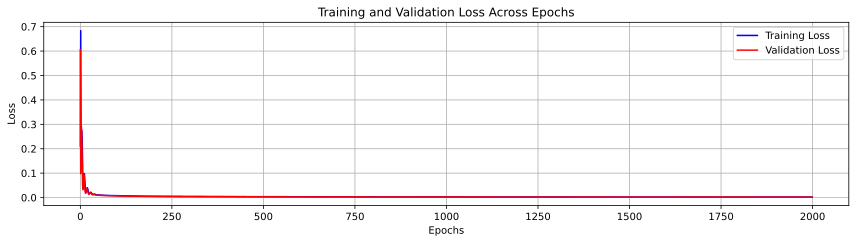

c:\Users\pmong\OneDrive - Università di Pavia\EPFL\Nonlinear_system_identification_modified\utils_SSM.py:258: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


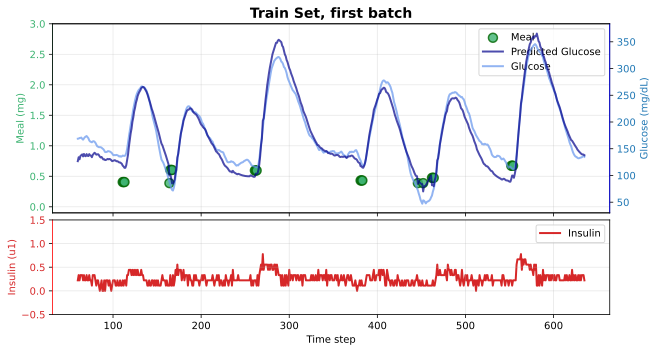

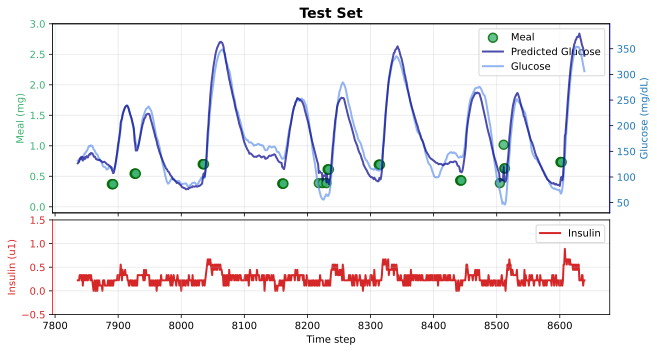

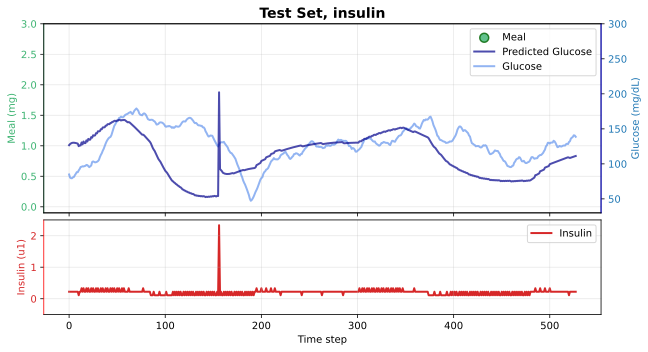

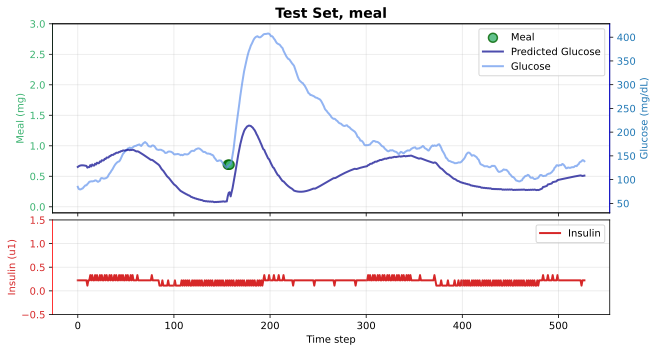

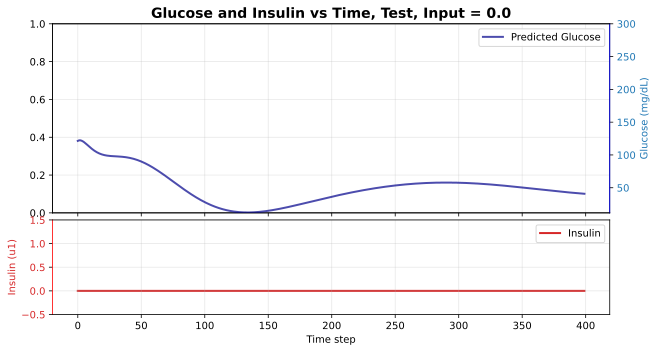

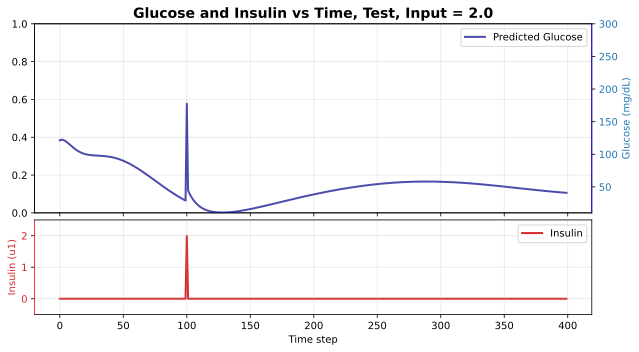

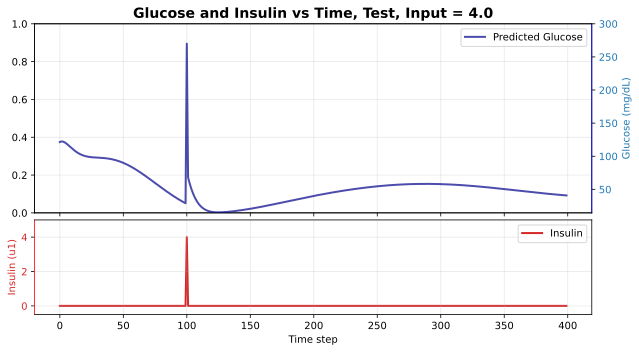

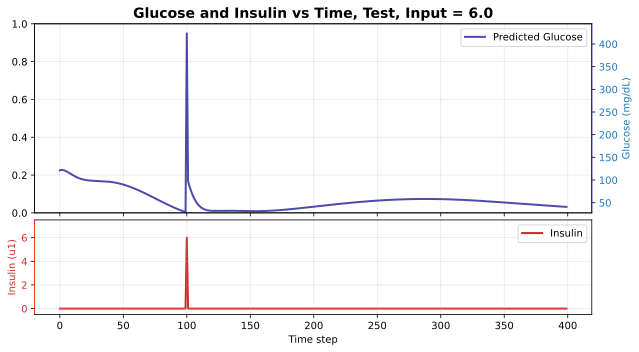

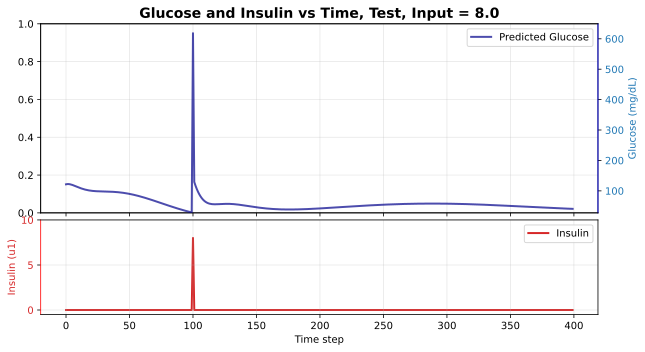

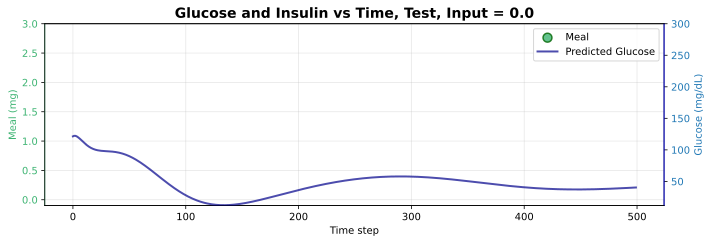

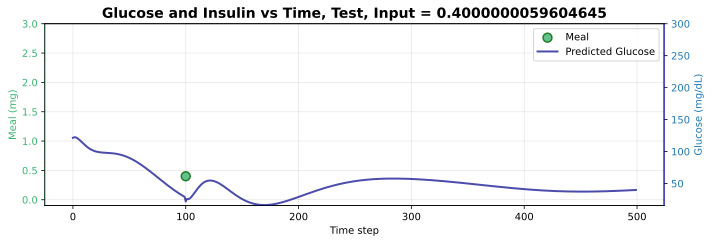

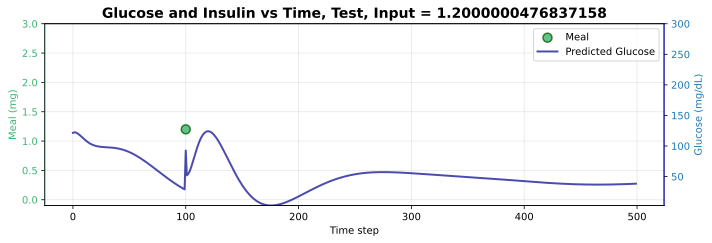

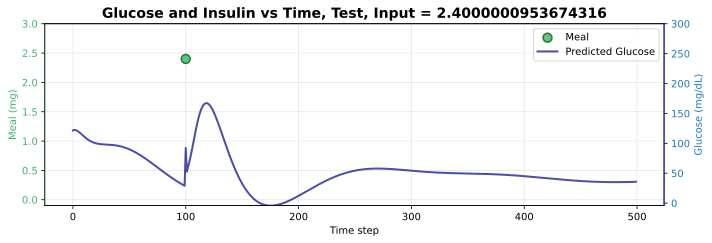

In [81]:

# --------------Plot identification results for G-----------------

patient_str = "/paz_" + str(int(patient)).zfill(3)
patient_model_folder = model_folder + "/strategy_1" + "/" + patient_str
MODEL_PATH = Path(patient_model_folder)
PARAM_PATH = MODEL_PATH / "params" / "parameters.mat"
params = scipy.io.loadmat(PARAM_PATH)

x0          = torch.tensor(params['x0'])
input_dim   = params["input_dim"].flatten().astype(int).tolist()
output_dim  = params["output_dim"].flatten().astype(int).tolist()
dim_internal= params["dim_internal"].flatten().astype(int).tolist()
dim_nl      = params["dim_nl"].flatten().astype(int).tolist()

y_init      = torch.tensor(params['y_init'])
gamma       = torch.tensor(params['gamma']).flatten()

train_losses = params["train_losses"][0]
val_losses   = params["val_losses"][0]
epoch_best   = int(params["epoch_when_model_saved"][0])

epochs = 2000


# ----------------------------------

#Training and Validation Loss Across Epochs
plt.figure(figsize=(12, 3.5))
plt.plot(range(epochs), train_losses, label='Training Loss', color='blue')
plt.plot(range(epochs), val_losses, label='Validation Loss', color='red')  # Assuming val_losses are collected
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Epochs')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


# ----------------------------------

SSM_0 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)
SSM_1 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)

checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")

SSM_0.load_state_dict(checkpoint["SSM_0_state_dict"])
SSM_1.load_state_dict(checkpoint["SSM_1_state_dict"])

SSM_0.eval()
SSM_1.eval()

for u0_batch, _, _, u1_batch, y_batch, time in train_loader_p:

    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    y_hat = y0_hat - y1_hat

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
    break # just first batch

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Train Set, first batch")



# -------------------------------------------------------------


for u0_batch, _, _, u1_batch, y_batch, time in test_loader:   # MH, I_rec (PID), R (noise + sat), I_sat (I_rec + R), CGM, time

    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    y_hat = y0_hat - y1_hat

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    


plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set")



# -------------------------------------------------------------

data_path = './data/test/sc_1_day_test_IR_insulin_30g_13h/'

loaded = sio.loadmat(f'{data_path}/s#adult#{patient:03d}.mat')

# Insulin suggestions saturated (effectively given by the pump)
I_data = loaded['injection']['signals'][0, 0]['values'][0, 0][1::5] / 6000  # now in U
I_data = I_data[:,0]
i = scaler_insulin.normalize(torch.from_numpy(I_data).float())
CGM = loaded['CGM']['signals'][0, 0]['values'][0, 0][1::5].flatten()
y = scaler_glucose.normalize(torch.from_numpy(CGM).float())
true_carbs_hypo_redone_05 = loaded['carb_intake']['signals'][0, 0]['values'][0, 0][1:-1:2].flatten()
MH = true_carbs_hypo_redone_05.reshape(-1, 5).sum(axis=1)
m = scaler_meal.normalize(torch.from_numpy(MH).float())

# --- Creazione di un Dataset custom ---
class TestDataset(Dataset):
    def __init__(self, MH, I, y, sequence_length=1):
        """
        MH: meal input (torch tensor)
        I: insulin input (torch tensor)
        y: output (glucose) (torch tensor)
        sequence_length: lunghezza sequenza temporale per la RNN/REN
        """
        self.MH = MH.unsqueeze(-1) if MH.ndim==1 else MH  # shape (N,1)
        self.I  = I.unsqueeze(-1) if I.ndim==1 else I
        self.y  = y.unsqueeze(-1) if y.ndim==1 else y
        self.seq_len = sequence_length

    def __len__(self):
        return len(self.y) - self.seq_len + 1

    def __getitem__(self, idx):
        u0_seq = self.MH[idx:idx+self.seq_len]
        u1_seq = self.I[idx:idx+self.seq_len]
        y_seq  = self.y[idx:idx+self.seq_len]
        time_seq = torch.arange(idx, idx+self.seq_len)
        return u0_seq, u1_seq, y_seq, time_seq


test_dataset_new = TestDataset(MH=m, I=i, y=y, sequence_length=len(y))
test_loader_new = DataLoader( test_dataset_new, batch_size=1, shuffle=False)


for u0_batch, u1_batch, y_batch, time in test_loader_new:
    
    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    y_hat = y0_hat - y1_hat

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, insulin")


# -------------------------------------------------------------

data_path = './data/test/sc_1_day_test_IR_meal_80g_13h/'

loaded = sio.loadmat(f'{data_path}/s#adult#{patient:03d}.mat')

# Insulin suggestions saturated (effectively given by the pump)
I_data = loaded['injection']['signals'][0, 0]['values'][0, 0][1::5] / 6000  # now in U
I_data = I_data[:,0]
i = scaler_insulin.normalize(torch.from_numpy(I_data).float())
CGM = loaded['CGM']['signals'][0, 0]['values'][0, 0][1::5].flatten()
y = scaler_glucose.normalize(torch.from_numpy(CGM).float())
true_carbs_hypo_redone_05 = loaded['carb_intake']['signals'][0, 0]['values'][0, 0][1:-1:2].flatten()
MH = true_carbs_hypo_redone_05.reshape(-1, 5).sum(axis=1)
m = scaler_meal.normalize(torch.from_numpy(MH).float())

test_dataset_new = TestDataset(MH=m, I=i, y=y, sequence_length=len(y))
test_loader_new = DataLoader(test_dataset_new, batch_size=1, shuffle=False)

    
for u0_batch, u1_batch, y_batch, time in test_loader_new:
    
    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    y_hat = y0_hat - y1_hat

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
    plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, meal")
    


# prima non era propriamente corretto, controllare ora se propriamente corretto: il modello è il closed loop non il dual ren
# in questo modo vedo se effettivamente la condizione di monotonicità è rispettata o cisono degli errori in giro
# ------------------------- fake insulin ------------------------------------

fake_insulins = [0, 2, 4, 6, 8]

for sample in  fake_insulins:

    Sim_time = 2000
    Ts = 5
    fake_time = np.arange(0, Sim_time, Ts)

    fake_meal = np.zeros(Sim_time//Ts)
    fake_meal = torch.from_numpy(fake_meal).float()

    fake_insulin = np.zeros(Sim_time//Ts)
    fake_insulin[100] = sample
    fake_insulin = torch.from_numpy(fake_insulin).float()

    fake_meal = fake_meal[None,:, None];   fake_insulin = fake_insulin[None,:, None]
    SSM_0.eval();                          SSM_1.eval()

    y0_hat, _ = SSM_0(fake_meal)
    y1_hat, _ = SSM_1(fake_insulin)
    y_hat = y0_hat - y1_hat
    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()

    time = torch.arange(len(y_fake[0,:,0]))[None,:,None]
    plot_glucose_insulin(time[0,:,0].numpy(), insulin=fake_insulin[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_insulin[0,100,0].numpy()}")



# ------------------------- fake meal ------------------------------------

fake_meals = [0, 0.4, 0.4*3, 0.4*6]

for sample in  fake_meals:
    fake_meal = np.zeros(500)
    fake_meal[100] = sample
    fake_meal = torch.from_numpy(fake_meal).float()
    fake_insulin = np.zeros(500)
    fake_insulin = torch.from_numpy(fake_insulin).float()

    fake_meal = fake_meal[None,:, None];    fake_insulin = fake_insulin[None,:, None]
    SSM_0.eval();                           SSM_1.eval()

    y0_hat, _ = SSM_0(fake_meal)
    y1_hat, _ = SSM_1(fake_insulin)
    y_hat = y0_hat - y1_hat
    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()

    time = torch.arange(len(y_fake[0,:,0]))[None,:,None]
    plot_glucose_insulin(time[0,:,0].numpy(), meal=fake_meal[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_meal[0,100,0].numpy()}")




C:\Users\pmong\AppData\Local\Temp\ipykernel_16852\1324477468.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  epoch_best   = int(params["epoch_when_model_saved"][0])


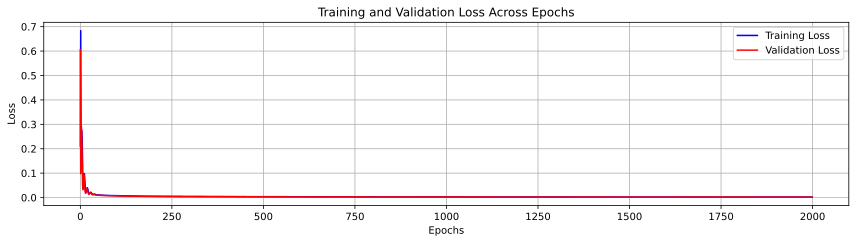

c:\Users\pmong\OneDrive - Università di Pavia\EPFL\Nonlinear_system_identification_modified\utils_SSM.py:258: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


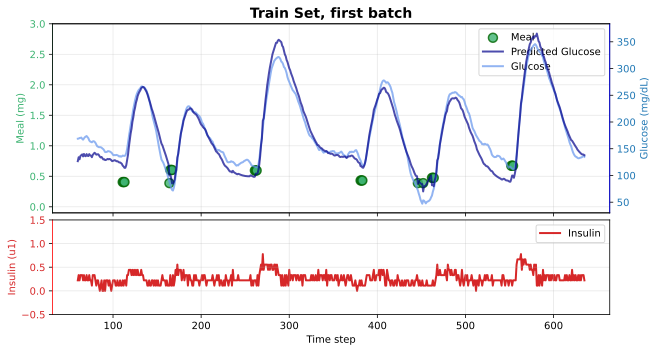

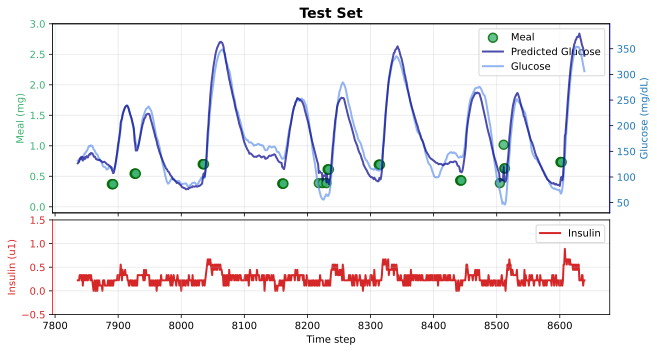

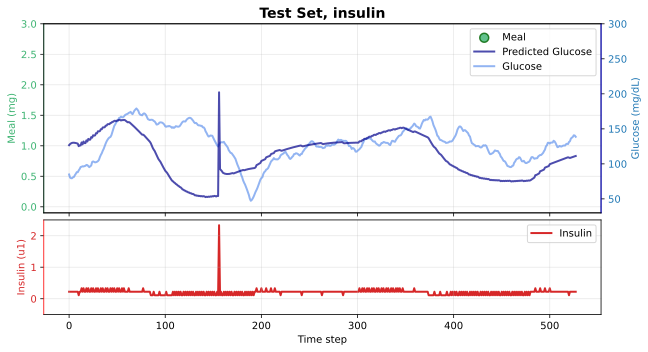

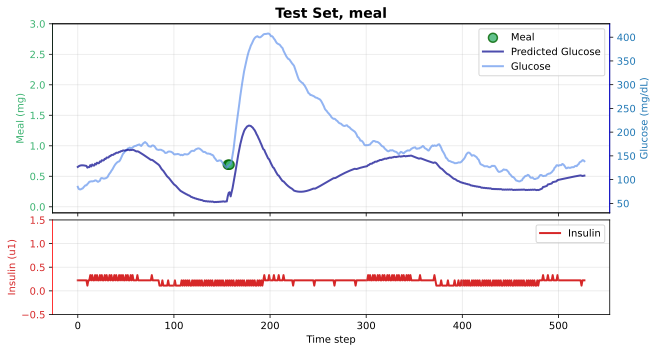

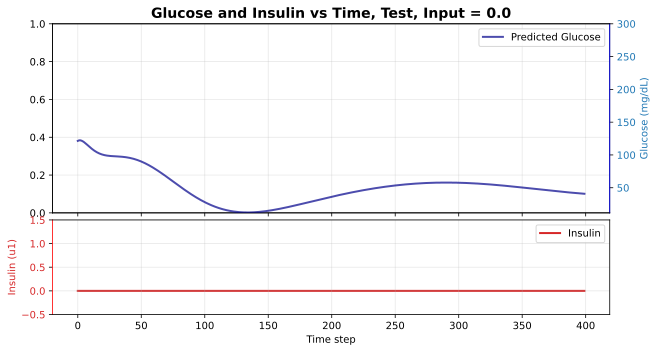

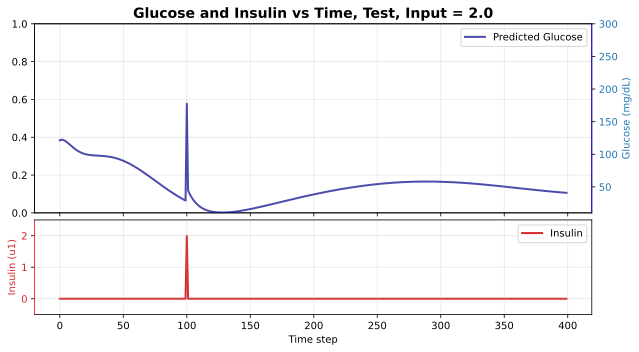

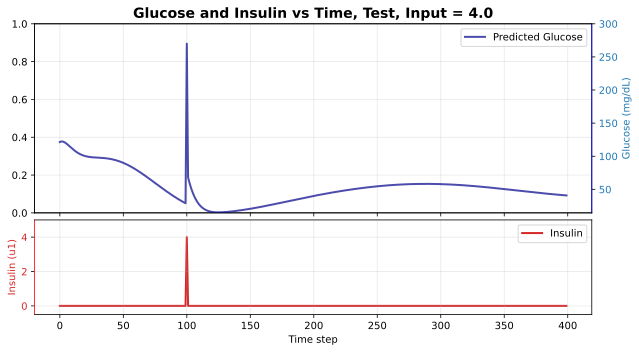

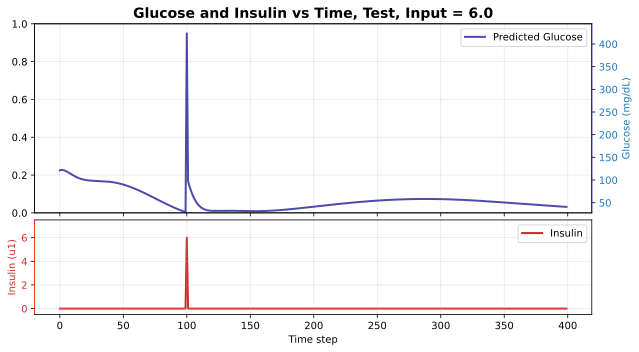

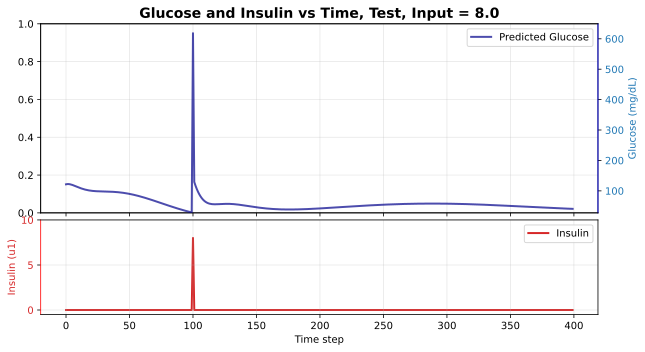

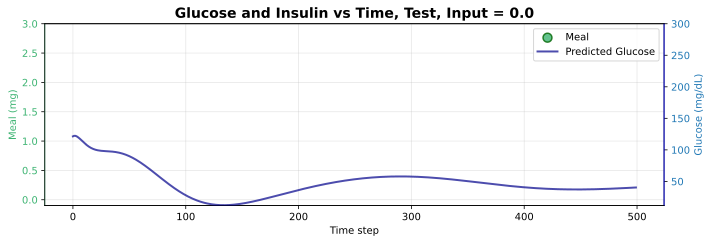

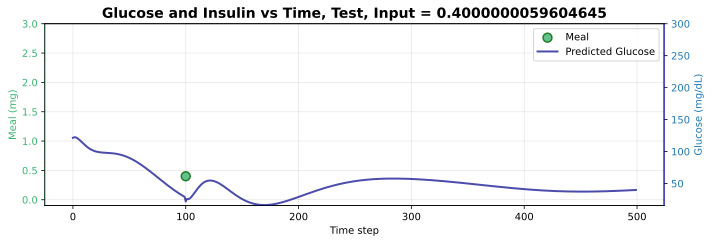

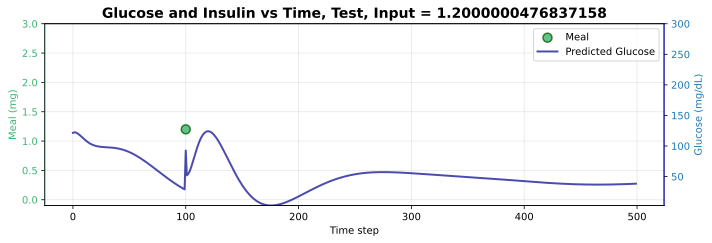

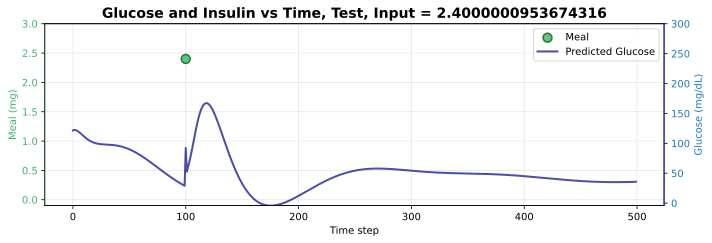

In [ ]:

# --------------Plot identification results for G-----------------

patient_str = "/paz_" + str(int(patient)).zfill(3)
patient_model_folder = model_folder + "/strategy_1" + "/" + patient_str
MODEL_PATH = Path(patient_model_folder)
PARAM_PATH = MODEL_PATH / "params" / "parameters.mat"
params = scipy.io.loadmat(PARAM_PATH)

x0          = torch.tensor(params['x0'])
input_dim   = params["input_dim"].flatten().astype(int).tolist()
output_dim  = params["output_dim"].flatten().astype(int).tolist()
dim_internal= params["dim_internal"].flatten().astype(int).tolist()
dim_nl      = params["dim_nl"].flatten().astype(int).tolist()

y_init      = torch.tensor(params['y_init'])
gamma       = torch.tensor(params['gamma']).flatten()

train_losses = params["train_losses"][0]
val_losses   = params["val_losses"][0]
epoch_best   = int(params["epoch_when_model_saved"][0])

epochs = 2000


# ----------------------------------

#Training and Validation Loss Across Epochs
plt.figure(figsize=(12, 3.5))
plt.plot(range(epochs), train_losses, label='Training Loss', color='blue')
plt.plot(range(epochs), val_losses, label='Validation Loss', color='red')  # Assuming val_losses are collected
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Epochs')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


# ----------------------------------

SSM_0 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)
SSM_1 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)

checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")

SSM_0.load_state_dict(checkpoint["SSM_0_state_dict"])
SSM_1.load_state_dict(checkpoint["SSM_1_state_dict"])

SSM_0.eval()
SSM_1.eval()

for u0_batch, _, _, u1_batch, y_batch, time in train_loader_p:

    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    y_hat = y0_hat - y1_hat

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
    break # just first batch

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Train Set, first batch")



# -------------------------------------------------------------


for u0_batch, _, _, u1_batch, y_batch, time in test_loader:   # MH, I_rec (PID), R (noise + sat), I_sat (I_rec + R), CGM, time

    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    y_hat = y0_hat - y1_hat

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    


plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set")



# -------------------------------------------------------------

data_path = './data/test/sc_1_day_test_IR_insulin_30g_13h/'

loaded = sio.loadmat(f'{data_path}/s#adult#{patient:03d}.mat')

# Insulin suggestions saturated (effectively given by the pump)
I_data = loaded['injection']['signals'][0, 0]['values'][0, 0][1::5] / 6000  # now in U
I_data = I_data[:,0]
i = scaler_insulin.normalize(torch.from_numpy(I_data).float())
CGM = loaded['CGM']['signals'][0, 0]['values'][0, 0][1::5].flatten()
y = scaler_glucose.normalize(torch.from_numpy(CGM).float())
true_carbs_hypo_redone_05 = loaded['carb_intake']['signals'][0, 0]['values'][0, 0][1:-1:2].flatten()
MH = true_carbs_hypo_redone_05.reshape(-1, 5).sum(axis=1)
m = scaler_meal.normalize(torch.from_numpy(MH).float())

# --- Creazione di un Dataset custom ---
class TestDataset(Dataset):
    def __init__(self, MH, I, y, sequence_length=1):
        """
        MH: meal input (torch tensor)
        I: insulin input (torch tensor)
        y: output (glucose) (torch tensor)
        sequence_length: lunghezza sequenza temporale per la RNN/REN
        """
        self.MH = MH.unsqueeze(-1) if MH.ndim==1 else MH  # shape (N,1)
        self.I  = I.unsqueeze(-1) if I.ndim==1 else I
        self.y  = y.unsqueeze(-1) if y.ndim==1 else y
        self.seq_len = sequence_length

    def __len__(self):
        return len(self.y) - self.seq_len + 1

    def __getitem__(self, idx):
        u0_seq = self.MH[idx:idx+self.seq_len]
        u1_seq = self.I[idx:idx+self.seq_len]
        y_seq  = self.y[idx:idx+self.seq_len]
        time_seq = torch.arange(idx, idx+self.seq_len)
        return u0_seq, u1_seq, y_seq, time_seq


test_dataset_new = TestDataset(MH=m, I=i, y=y, sequence_length=len(y))
test_loader_new = DataLoader( test_dataset_new, batch_size=1, shuffle=False)


for u0_batch, u1_batch, y_batch, time in test_loader_new:
    
    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    y_hat = y0_hat - y1_hat

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, insulin")


# -------------------------------------------------------------

data_path = './data/test/sc_1_day_test_IR_meal_80g_13h/'

loaded = sio.loadmat(f'{data_path}/s#adult#{patient:03d}.mat')

# Insulin suggestions saturated (effectively given by the pump)
I_data = loaded['injection']['signals'][0, 0]['values'][0, 0][1::5] / 6000  # now in U
I_data = I_data[:,0]
i = scaler_insulin.normalize(torch.from_numpy(I_data).float())
CGM = loaded['CGM']['signals'][0, 0]['values'][0, 0][1::5].flatten()
y = scaler_glucose.normalize(torch.from_numpy(CGM).float())
true_carbs_hypo_redone_05 = loaded['carb_intake']['signals'][0, 0]['values'][0, 0][1:-1:2].flatten()
MH = true_carbs_hypo_redone_05.reshape(-1, 5).sum(axis=1)
m = scaler_meal.normalize(torch.from_numpy(MH).float())

test_dataset_new = TestDataset(MH=m, I=i, y=y, sequence_length=len(y))
test_loader_new = DataLoader(test_dataset_new, batch_size=1, shuffle=False)

    
for u0_batch, u1_batch, y_batch, time in test_loader_new:
    
    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    y_hat = y0_hat - y1_hat

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
    plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, meal")
    


# prima non era propriamente corretto, controllare ora se propriamente corretto: il modello è il closed loop non il dual ren
# in questo modo vedo se effettivamente la condizione di monotonicità è rispettata o cisono degli errori in giro
# ------------------------- fake insulin ------------------------------------

fake_insulins = [0, 2, 4, 6, 8]

for sample in  fake_insulins:

    Sim_time = 2000
    Ts = 5
    fake_time = np.arange(0, Sim_time, Ts)

    fake_meal = np.zeros(Sim_time//Ts)
    fake_meal = torch.from_numpy(fake_meal).float()

    fake_insulin = np.zeros(Sim_time//Ts)
    fake_insulin[100] = sample
    fake_insulin = torch.from_numpy(fake_insulin).float()

    fake_meal = fake_meal[None,:, None];   fake_insulin = fake_insulin[None,:, None]
    SSM_0.eval();                          SSM_1.eval()

    y0_hat, _ = SSM_0(fake_meal)
    y1_hat, _ = SSM_1(fake_insulin)
    y_hat = y0_hat - y1_hat
    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()

    time = torch.arange(len(y_fake[0,:,0]))[None,:,None]
    plot_glucose_insulin(time[0,:,0].numpy(), insulin=fake_insulin[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_insulin[0,100,0].numpy()}")



# ------------------------- fake meal ------------------------------------

fake_meals = [0, 0.4, 0.4*3, 0.4*6]

for sample in  fake_meals:
    fake_meal = np.zeros(500)
    fake_meal[100] = sample
    fake_meal = torch.from_numpy(fake_meal).float()
    fake_insulin = np.zeros(500)
    fake_insulin = torch.from_numpy(fake_insulin).float()

    fake_meal = fake_meal[None,:, None];    fake_insulin = fake_insulin[None,:, None]
    SSM_0.eval();                           SSM_1.eval()

    y0_hat, _ = SSM_0(fake_meal)
    y1_hat, _ = SSM_1(fake_insulin)
    y_hat = y0_hat - y1_hat
    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()

    time = torch.arange(len(y_fake[0,:,0]))[None,:,None]
    plot_glucose_insulin(time[0,:,0].numpy(), meal=fake_meal[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_meal[0,100,0].numpy()}")




# System identification of the negative feedback of K and S

### Closed loop model of REN in negative feedback with K, loss function and optimizer

In [ ]:
#-----------------------------closedloop sysid of S through RENs------------------------
#--------------------------Define model for sysid---------------------------------------------
#create the REN model for S


patient_model_folder_101_M = f"./models/SSM/101_M/{exp_identifier}"
MODEL_PATH = Path(patient_model_folder_101_M)
checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_0_101.load_state_dict(checkpoint["SSM_0_101_state_dict"])
# posso caricare solo M

SSM_0 = copy.deepcopy(SSM_0_101.to(device))
SSM_S = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)


Dual_SSM = DualSSM(SSM_0, SSM_S, device=device)

controller = NonLinearController_p2(loaded_parameters, PID_functions, dataset.basal_vec, scaler_glucose, scaler_insulin, scaler_meal, use_noise = use_noise)
closed_loop_SSM = ClosedLoopSystem_SSM(Dual_SSM, controller, negative=True)
closed_loop_closed_loop_1 = ClosedLoopSystem_SSM(closed_loop_SSM, controller)

#--------------------------Define the loss function and optimizer---------------------------------------------
MSE = nn.MSELoss()
optimizer = torch.optim.Adam(Dual_SSM.parameters(), lr=learning_rate)
optimizer.zero_grad()


### Training and validation loop

In [ ]:
#--------------------------5. Training---------------------------------------------------------------------

SSM_0, SSM_S, Dual_SSM, controller, closed_loop_SSM = SSM_0.to(device), SSM_S.to(device), Dual_SSM.to(device), controller.to(device), closed_loop_SSM.to(device)

epochs = 1

print(f"[INFO] Training on device: {device}")

closed_loop_closed_loop_1 = closed_loop_closed_loop_1.to("cpu") # test always on cpu?
torch.set_default_dtype(torch.float32)  # default tensor dtype

train_losses = []
val_losses = []  # Store validation losses across epochs

for epoch in range(epochs):
    # ---------------- TRAINING ---------------- #
    closed_loop_SSM.train()
    loss_epoch = 0.0  # Accumulate training loss

    for u0_batch, _, _, u1_batch, y_batch, t_batch in train_loader_p: # MH, I_rec (PID), R (noise + sat), I_sat (I_rec + R), CGM, time
        # u_batch.shape = batch_size   horizon   input_dim
        
        u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(t_batch) # batch_size, time_horizon, input_dim
        u0_batch, u1_batch, y_batch, t_batch = u0_batch.to(device), u1_batch.to(device), y_batch.to(device), t_batch.to(device)
        u_batch = torch.cat((u0_batch, u1_batch), dim=2)  # concatenate along input dimension

        optimizer.zero_grad()
        
        saturation_error_init, glucose_PID_init, _ = fun_start_controller(train_loader_p, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
        closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
        
                
        _, y_hat_train = closed_loop_SSM(u_batch, t_batch, y0 = y_batch[:,:1,:1])

        if torch.isnan(y_hat_train).any() or torch.isinf(y_hat_train).any():
            y_hat_train = torch.nan_to_num(y_hat_train, nan=1e5, posinf=1e5, neginf=-1e5)
            for name, param in closed_loop_SSM.named_parameters():
                print(f"{name}: mean {param.data.mean()}, std {param.data.std()}")

        loss_batch = MSE(y_hat_train, y_batch)
        loss_batch.backward()
        # torch.nn.utils.clip_grad_norm_(Dual_REN.parameters(), max_norm=1.0) # Gradient clipping TODO: check if other code is correct
        optimizer.step()
        loss_epoch += loss_batch.item()

    loss_epoch /= len(train_loader_p)
    train_losses.append(loss_epoch)

    # ---------------- VALIDATION ---------------- #
    Dual_SSM.eval()
    loss_val_epoch = 0.0

    with torch.no_grad():
        for u0_batch, _, _, u1_batch, y_batch, t_batch in val_loader: # MH, I_rec (PID), R (noise + sat), I_sat (I_rec + R), CGM, time
            # u_batch.shape = batch_size   horizon   input_dim
            
            u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(t_batch) # batch_size, time_horizon, input_dim
            u_batch = torch.cat((u0_batch, u1_batch), dim=2)  # concatenate along input dimension
            u_batch, y_batch, t_batch = u_batch.to(device), y_batch.to(device), t_batch.to(device)
                        
            saturation_error_init, glucose_PID_init, _ = fun_start_controller(val_loader, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
            closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
                    
            _, y_hat_val = closed_loop_SSM(u_batch, t_batch, y0 = y_batch[:,:1,:1])
            
            loss_batch_val = MSE(y_hat_val, y_batch)
            loss_val_epoch += loss_batch_val.item()

    if epoch == 0 or loss_val_epoch < min_val_loss:
        min_val_loss = loss_val_epoch
        epoch_when_model_saved = epoch
        candidate_Dual_SSM = Dual_SSM

    loss_val_epoch /= len(val_loader)
    val_losses.append(loss_val_epoch)  # Store validation loss for plotting

    if epoch % 10 == 0:
        print(f"Epoch: {epoch + 1} \t||\t Training Loss: {loss_epoch:.6f} \t||\t Validation Loss: {loss_val_epoch:.6f}")

if redo_save:
    # model on CPU before saving
    candidate_Dual_SSM_cpu = candidate_Dual_SSM.to('cpu')

    # Save the best model
    # 1. Create models directory
    patient_str = "/paz_" + str(int(patient)).zfill(3)
    patient_model_folder = model_folder + "/"+ "strategy_2" + "/" + patient_str
    MODEL_PATH = Path(patient_model_folder)
    MODEL_PATH.mkdir(parents = True, exist_ok = True)
    # 2. save model state dict
    torch.save({'Dual_SSM_state_dict': candidate_Dual_SSM_cpu.state_dict()}, MODEL_PATH / 'trained_models.pth')

    # save .mat
    np_x0 = x0.detach().cpu().numpy(); np_input_dim = np.array(input_dim); np_output_dim = np.array(output_dim); np_dim_internal =np.array(dim_internal); np_dim_nl = np.array(dim_nl)
    np_y_init = y_init.cpu().numpy(); np_gamma = gamma.cpu().numpy()
    
    # 4. Create params directory
    params_folder = Path(patient_model_folder) / "params"
    params_folder.mkdir(parents=True, exist_ok=True)
    scipy.io.savemat(params_folder / 'parameters.mat', {'train_losses': train_losses, 'val_losses': val_losses, 'epoch_when_model_saved': epoch_when_model_saved, 'x0': np_x0, 'input_dim': np_input_dim, 'output_dim': np_output_dim, 'dim_internal': np_dim_internal, 'dim_nl': np_dim_nl, 'y_init': np_y_init, 'gamma': np_gamma})

### Plots: identification results for the negative feedback of S and K

In [ ]:
# --------------Plot identification results for G-----------------

epochs = 1;

patient_str = "/paz_" + str(int(patient)).zfill(3)
patient_model_folder = model_folder + "/strategy_2" + "/" + patient_str
MODEL_PATH = Path(patient_model_folder)
PARAM_PATH = MODEL_PATH / "params" / "parameters.mat"
params = scipy.io.loadmat(PARAM_PATH)

x0          = torch.tensor(params['x0'])
input_dim   = params["input_dim"].flatten().astype(int).tolist()
output_dim  = params["output_dim"].flatten().astype(int).tolist()
dim_internal= params["dim_internal"].flatten().astype(int).tolist()
dim_nl      = params["dim_nl"].flatten().astype(int).tolist()

y_init      = torch.tensor(params['y_init'])
gamma       = torch.tensor(params['gamma']).flatten()

train_losses = params["train_losses"][0]
val_losses   = params["val_losses"][0]
epoch_best   = int(params["epoch_when_model_saved"][0])


# ----------------------------------


#Training and Validation Loss Across Epochs
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_losses, label='Training Loss', color='blue')
plt.plot(range(epochs), val_losses, label='Validation Loss', color='red')  # Assuming val_losses are collected
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Epochs')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()



SSM_0 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8, ff='GLU', param='l2n', d_state=8, n_layers=7, max_phase_b=0.04,  d_hidden=12, dim_amp=3)  
SSM_1 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8, ff='GLU', param='l2n', d_state=8, n_layers=7, max_phase_b=0.04,  d_hidden=12, dim_amp=3)  
Dual_SSM = DualSSM(SSM_0, SSM_1, device=device)
controller = NonLinearController_p2(loaded_parameters, PID_functions, dataset.basal_vec, scaler_glucose, scaler_insulin, scaler_meal, use_noise = use_noise)
closed_loop_SSM = ClosedLoopSystem_SSM(Dual_SSM, controller, negative=True)

checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
Dual_SSM.load_state_dict(checkpoint["Dual_SSM_state_dict"])


Dual_SSM.eval()



for u0_batch, _, _, u1_batch, y_batch, t_batch in train_loader_p:

    u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(t_batch) # batch_size, time_horizon, input_dim
    u0_batch, u1_batch, y_batch, t_batch = u0_batch.to(device), u1_batch.to(device), y_batch.to(device), t_batch.to(device)
    u_batch = torch.cat((u0_batch, u1_batch), dim=2)
    
    saturation_error_init, glucose_PID_init, _ = fun_start_controller(train_loader_p, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
    closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
            
    _, y_hat_train = closed_loop_SSM(u_batch, t_batch, y0 = y_batch[:,:1,:1])  

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat_train.detach().cpu()).numpy()
    time_plot = t_batch.detach().cpu()
    
    break # just first batch

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Train Set, first batch")




for u0_batch, _, _, u1_batch, y_batch, t_batch in test_loader:

    u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(t_batch) # batch_size, time_horizon, input_dim
    u0_batch, u1_batch, y_batch, t_batch = u0_batch.to(device), u1_batch.to(device), y_batch.to(device), t_batch.to(device)
    
    u_batch = torch.cat((u0_batch, u1_batch), dim=2)  # concatenate along input di
    
    saturation_error_init, glucose_PID_init, _ = fun_start_controller(test_loader, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
    closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
    
    _, y_hat = closed_loop_SSM(u_batch, t_batch, y0 = y_batch[:,:1,:1])  

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = t_batch.detach().cpu()
    

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set")


# -------------------------------------------------------------

data_path = './data/test/sc_1_day_test_IR_insulin_30g_13h/'

loaded = sio.loadmat(f'{data_path}/s#adult#{patient:03d}.mat')

# Insulin suggestions saturated (effectively given by the pump)
I_data = loaded['injection']['signals'][0, 0]['values'][0, 0][1::5] / 6000  # now in U
I_data = I_data[:,0]
i = scaler_insulin.normalize(torch.from_numpy(I_data).float())
CGM = loaded['CGM']['signals'][0, 0]['values'][0, 0][1::5].flatten()
y = scaler_glucose.normalize(torch.from_numpy(CGM).float())
true_carbs_hypo_redone_05 = loaded['carb_intake']['signals'][0, 0]['values'][0, 0][1:-1:2].flatten()
MH = true_carbs_hypo_redone_05.reshape(-1, 5).sum(axis=1)
m = scaler_meal.normalize(torch.from_numpy(MH).float())

# --- Creazione di un Dataset custom ---
class TestDataset(Dataset):
    def __init__(self, MH, I, y, sequence_length=1):
        """
        MH: meal input (torch tensor)
        I: insulin input (torch tensor)
        y: output (glucose) (torch tensor)
        sequence_length: lunghezza sequenza temporale per la RNN/REN
        """
        self.MH = MH.unsqueeze(-1) if MH.ndim==1 else MH  # shape (N,1)
        self.I  = I.unsqueeze(-1) if I.ndim==1 else I
        self.y  = y.unsqueeze(-1) if y.ndim==1 else y
        self.seq_len = sequence_length

    def __len__(self):
        return len(self.y) - self.seq_len + 1

    def __getitem__(self, idx):
        u0_seq = self.MH[idx:idx+self.seq_len]
        u1_seq = self.I[idx:idx+self.seq_len]
        y_seq  = self.y[idx:idx+self.seq_len]
        time_seq = torch.arange(idx, idx+self.seq_len)
        return u0_seq, u1_seq, y_seq, time_seq


test_dataset_new = TestDataset(MH=m, I=i, y=y, sequence_length=len(y))
test_loader_new = DataLoader(test_dataset_new, batch_size=1, shuffle=False)

for u0_batch, u1_batch, y_batch, time in test_loader_new:

    u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)
    u_batch = torch.cat((u0_batch, u1_batch), dim=2)  # concatenate along input di
    
    saturation_error_init, glucose_PID_init, _ = fun_start_controller(test_loader_new, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
    closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
    
    _, y_hat = closed_loop_SSM(u_batch, t_batch, y0 = y_batch[:,:1,:1])  

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = t_batch.detach().cpu()

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, insulin")

# -------------------------------------------------------------

data_path = './data/test/sc_1_day_test_IR_meal_80g_13h/'

loaded = sio.loadmat(f'{data_path}/s#adult#{patient:03d}.mat')

# Insulin suggestions saturated (effectively given by the pump)
I_data = loaded['injection']['signals'][0, 0]['values'][0, 0][1::5] / 6000  # now in U
I_data = I_data[:,0]
i = scaler_insulin.normalize(torch.from_numpy(I_data).float())
CGM = loaded['CGM']['signals'][0, 0]['values'][0, 0][1::5].flatten()
y = scaler_glucose.normalize(torch.from_numpy(CGM).float())
true_carbs_hypo_redone_05 = loaded['carb_intake']['signals'][0, 0]['values'][0, 0][1:-1:2].flatten()
MH = true_carbs_hypo_redone_05.reshape(-1, 5).sum(axis=1)
m = scaler_meal.normalize(torch.from_numpy(MH).float())

test_dataset_new = TestDataset(MH=m, I=i, y=y, sequence_length=len(y))
test_loader_new = DataLoader(test_dataset_new, batch_size=1, shuffle=False)


for u0_batch, u1_batch, y_batch, time in test_loader_new:

    u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)
    u_batch = torch.cat((u0_batch, u1_batch), dim=2)  # concatenate along input di
    
    
    saturation_error_init, glucose_PID_init, _ = fun_start_controller(test_loader_new, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
    closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
    
    _, y_hat = closed_loop_SSM(u_batch, t_batch, y0 = y_batch[:,:1,:1])  

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = t_batch.detach().cpu()


plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, meal")




# prima non era propriamente corretto, controllare ora se propriamente corretto: il modello è il closed loop non il dual ren
# in questo modo vedo se effettivamente la condizione di monotonicità è rispettata o cisono degli errori in giro
# ------------------------- fake insulin ------------------------------------

fake_insulins = [0, 2, 4, 6, 8]

for sample in  fake_insulins:

    Sim_time = 2000
    Ts = 5
    fake_time = np.arange(0, Sim_time, Ts)

    fake_meal = np.zeros(Sim_time//Ts)
    fake_meal = torch.from_numpy(fake_meal).float()

    fake_insulin = np.zeros(Sim_time//Ts)
    fake_insulin[100] = sample
    fake_insulin = torch.from_numpy(fake_insulin).float()
    
    t_batch = torch.arange(0, len(fake_insulin))
    
    t_batch = t_batch[None,:, None]
    fake_meal = fake_meal[None,:, None];   fake_insulin = fake_insulin[None,:, None]
    SSM_0.eval();                          SSM_1.eval()
    
    
    u_batch = torch.cat((fake_meal, fake_insulin), dim=2)
    
    closed_loop_SSM.reset()
    _, y_hat = closed_loop_SSM(u_batch, t_batch, y0 = y_batch[:,:1,:1])  

    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()

    plot_glucose_insulin(t_batch[0,:,0].numpy(), insulin=fake_insulin[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_insulin[0,100,0].numpy()}")



# ------------------------- fake meal ------------------------------------

fake_meals = [0, 0.4, 0.4*3, 0.4*6]

for sample in  fake_meals:
    fake_meal = np.zeros(500)
    fake_meal[100] = sample
    fake_meal = torch.from_numpy(fake_meal).float()
    fake_insulin = np.zeros(500)
    fake_insulin = torch.from_numpy(fake_insulin).float()

    t_batch = torch.arange(0, len(fake_insulin))
    
    t_batch = t_batch[None,:, None]
    fake_meal = fake_meal[None,:, None];   fake_insulin = fake_insulin[None,:, None]
    SSM_0.eval();                          SSM_1.eval()
    
    
    u_batch = torch.cat((fake_meal, fake_insulin), dim=2)
    
    closed_loop_SSM.reset()
    _, y_hat = closed_loop_SSM(u_batch, t_batch, y0 = y_batch[:,:1,:1])  

    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()

    plot_glucose_insulin(t_batch[0,:,0].numpy(), meal=fake_meal[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_meal[0,100,0].numpy()}")




